In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker

current_dir = os.getcwd()
module_path = os.path.abspath(os.path.join(current_dir, '../..', 'libs'))
if module_path not in sys.path:
    sys.path.append(module_path)

from SCOU_NC_Vanilla_NUTS_manual import *

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
def get_data_and_init_dicts(filepath):
    output_data = pd.read_excel(filepath, sheet_name='VIRUSES')
    
    viruses_list = output_data.iloc[1, 2:12].index.tolist()
    lods = output_data.iloc[1, 2:12].values.tolist()
    lods_dict = dict(zip(viruses_list, lods))

    output_data = output_data.loc[2:]
    output_data = output_data.drop('Unnamed: 0', axis=1)
    output_data.dateStart = pd.to_datetime(output_data.dateStart)
    output_data.reset_index(inplace=True, drop=True)
    
    for col in viruses_list + ['plantVolume']:
        output_data[col] = output_data[col].replace(' - ', np.nan)
        output_data[col] = pd.to_numeric(output_data[col])    

    return output_data, lods_dict, viruses_list

In [3]:
def get_sub_data(input_data, virus):
    this_lod = lods_dict[virus]
    
    output_data = input_data.copy()
    output_data = output_data.loc[::, ['dateStart', virus, 'plantVolume']]
    output_data.columns = ['dateStart', 'obs_conc', 'plantVolume']
    output_data['lod_conc'] = this_lod
    
    # for error checking purpose
    output_data['obs_raw'] = output_data.obs_conc.copy()
    output_data['lod_raw'] = output_data.lod_conc.copy()

    output_data.loc[output_data.obs_raw <= output_data.lod_raw, 'obs_raw'] = output_data.loc[output_data.obs_raw <= output_data.lod_raw, 'lod_raw']
    
    output_data['obs'] = output_data.obs_raw.copy() 
    output_data['lod'] = output_data.lod_raw.copy() 

    for col in ['obs', 'lod']:
        output_data[col] *= output_data['plantVolume']
        output_data[col] = np.log(output_data[col])
        
    # Mandatory for pixel perfect reproducibility because of (I assume) float precision during dataset export:
    if virus=='SARS-Cov2 (UG Gene E/L)':
        output_data.loc[output_data.dateStart=='2024-02-13', 'obs'] = 30.566107712899
        
    columns = ['dateStart', 'obs', 'lod', 'plantVolume', 'obs_raw', 'lod_raw'] 
    output_data = output_data.loc[::, columns]
    output_data = output_data.loc[~output_data.obs.isna()]
    output_data = output_data.set_index('dateStart').resample('D').mean().reset_index()  

    return output_data

In [4]:
def append_and_process_results(input_data, this_molecule, scou):
    input_data['muX'] = scou.muX
    input_data['ICL'] = scou.CIL
    input_data['ICU'] = scou.CIU
    input_data['pout'] = scou.pointwise_pout
    
    input_data.obs = np.log10(np.exp(input_data.obs))
    input_data.muX = np.log10(np.exp(input_data.muX))
    input_data.ICL = np.log10(np.exp(input_data.ICL))
    input_data.ICU = np.log10(np.exp(input_data.ICU))
    common_flux_data[this_molecule] = input_data.copy() 

    return input_data

In [5]:
def visualize_results(input_data, this_molecule):
    
    with plt.style.context(['science', 'notebook', 'grid']):

        LABEL_SIZE = 30
        TICK_SIZE = 30
        TITLE_SIZE = 38
        LEGEND_SIZE = 30
        DATES_SIZE = 18
        figsize = (28, 10) #figsize = (32, 10)
        
        plt.rc('axes', labelsize=LABEL_SIZE)
        plt.rc('xtick', labelsize=TICK_SIZE)   
        plt.rc('ytick', labelsize=TICK_SIZE)
        plt.rc('figure', titlesize=TITLE_SIZE)
        plt.rc('legend', fontsize=LEGEND_SIZE)
        plt.rcParams['text.usetex'] = True
        
        fig = plt.figure(figsize=figsize, layout="constrained")
        
        ax_dict = fig.subplot_mosaic(
            """
            A
            """
        )
        
        ### A
        ax_dict['A'].plot(input_data.dateStart.values, input_data.muX.values, label='$X^*_{t_{opt}}$', color='green', linewidth=8, zorder=3)
        
        ax_dict['A'].plot(input_data.dateStart.values, input_data.ICL.values, label='95% CI', linestyle='--', color='green', linewidth=5, zorder=1)
        ax_dict['A'].plot(input_data.dateStart.values, input_data.ICU.values, linestyle='--', color='green', linewidth=5, zorder=1)
        
        ax_dict['A'].fill_between(input_data.dateStart.values, input_data.ICL.values, input_data.ICU.values, alpha=.3, color='green')
    
        
        scatter_points = ax_dict['A'].scatter(input_data.dateStart.values, input_data.obs.values, label='$\hat{X}_t$', 
                             c=input_data.pout.values,
                             cmap='bwr', edgecolor='black', s=360, zorder=3,
                             linewidths=1.5, alpha=0.9, vmin=0, vmax=1)
    
        
        ax_dict['A'].set_ylabel("Concentration (UG/L) - $\log_{10}$ scale")
        ax_dict['A'].set_xlabel("Sampling date")
        ax_dict['A'].tick_params(axis='x', labelsize=TICK_SIZE)
        ax_dict['A'].tick_params(axis='y', labelsize=TICK_SIZE)
        ax_dict['A'].grid(linewidth=1, color='black', alpha=0.8)
        ax_dict['A'].set_title(this_molecule, size=TITLE_SIZE)
    
        ### Outlier probability legend:
        cmin, cmax = 0.0, 1.0 
        axins1 = inset_axes(ax_dict['A'], width='2%', height='100%', loc='right', borderpad=0)
        axins1.grid(False)
        cbar = fig.colorbar(scatter_points, cax=axins1, orientation='vertical')
        
        # Setting tick limits:
        cbar.set_ticks([cmin, cmax])
        cbar.ax.yaxis.set_major_locator(ticker.FixedLocator([cmin, cmax]))
        
        # Standardizing the float format displayed:
        decimal_places = 1
        cbar.ax.set_yticklabels([f"{cmin:.{decimal_places}f}", f"{cmax:.{decimal_places}f}"], fontsize=TICK_SIZE)
    
        # Placing the label at the right spot:
        cbar.ax.set_ylabel('Outlier probability', size=TICK_SIZE, labelpad=-35)
    
        # Main legend
        plt.rcParams['text.usetex'] = False
        h1, l1 = ax_dict['A'].get_legend_handles_labels()
        fig.legend(h1, l1, loc='upper center', bbox_to_anchor=(0.5, 0), fancybox=True, shadow=True, ncol=5)
        
        plt.show()

In [6]:
# SCOU general parameters:
nb_chains = 15
tuning_iters = 12000
sampling_iters = 2000

In [7]:
filepath = '../../data/Observatory_paper_mendeley.xlsx'
subraw_data, lods_dict, viruses_list = get_data_and_init_dicts(filepath)

scou_dict, sub_data_dict = {}, {}

In [ ]:
for this_virus in viruses_list:

    print("==========")
    print(this_virus)
    print("==========")
    
    sub_data = get_sub_data(subraw_data, this_virus)

    lod_vect = sub_data.lod.values
    observation_matrix = sub_data.obs.values
    
    scou = SCOU_RW1_NUTS(observation_matrix, lod_vect, tuning_iters=tuning_iters, sampling_iters=sampling_iters,
                                 export_name=None, 
                                 p_out_frozen=-1, nb_chains=nb_chains, export_chains=False,
                                 RW_order=1)
    scou.fit()

    selected_chains = np.arange(nb_chains).tolist()
    remove_those = []
    for i in remove_those:
        selected_chains.remove(i)
    
    scou.visualize_latents(selected_chains)
    scou.predict(selected_chains)

    scou_dict[this_virus] = scou

In [13]:
chain_selector_dict = {}
chain_selector_dict['Crassphage'] = [1, 11, 8, 12]
chain_selector_dict['PMMoV (Pepper mild mottle virus)'] = [2]
chain_selector_dict['Astrovirus (8 serotypes)'] = []
chain_selector_dict['Norovirus-GI'] = []
chain_selector_dict['Norovirus-GII'] = [2]
chain_selector_dict['Aichi virus A'] = [11, 2, 6, 12]
chain_selector_dict['enterovirus (ABCD)'] = [3, 13, 1, 5]
chain_selector_dict['SAPOVIRUS GI/GII/GIV'] = [13]
chain_selector_dict['SARS-Cov2 (UG Gene E/L)'] = [10]
chain_selector_dict['Rotavirus G1P[8], G2P[4], G3P[8], G4P[8], G9P[8] et G12P[8] (8G12)'] = []

In [14]:
for this_parameter in viruses_list:
    
    sub_data = get_sub_data(subraw_data, this_parameter)
    sub_data_dict[this_parameter] = sub_data

Crassphage


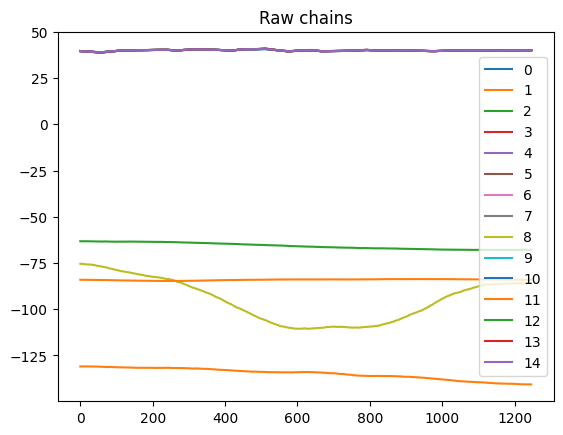

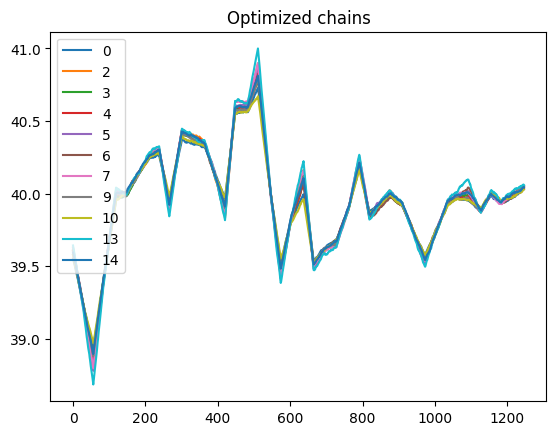

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.110  0.027   0.063    0.158      0.004    0.003      55.0     181.0   
eps    0.396  0.124   0.173    0.629      0.003    0.002    1723.0    6749.0   
p_out  0.149  0.062   0.046    0.268      0.001    0.000    7938.0   12723.0   

       r_hat  
sig     1.17  
eps     1.01  
p_out   1.00  


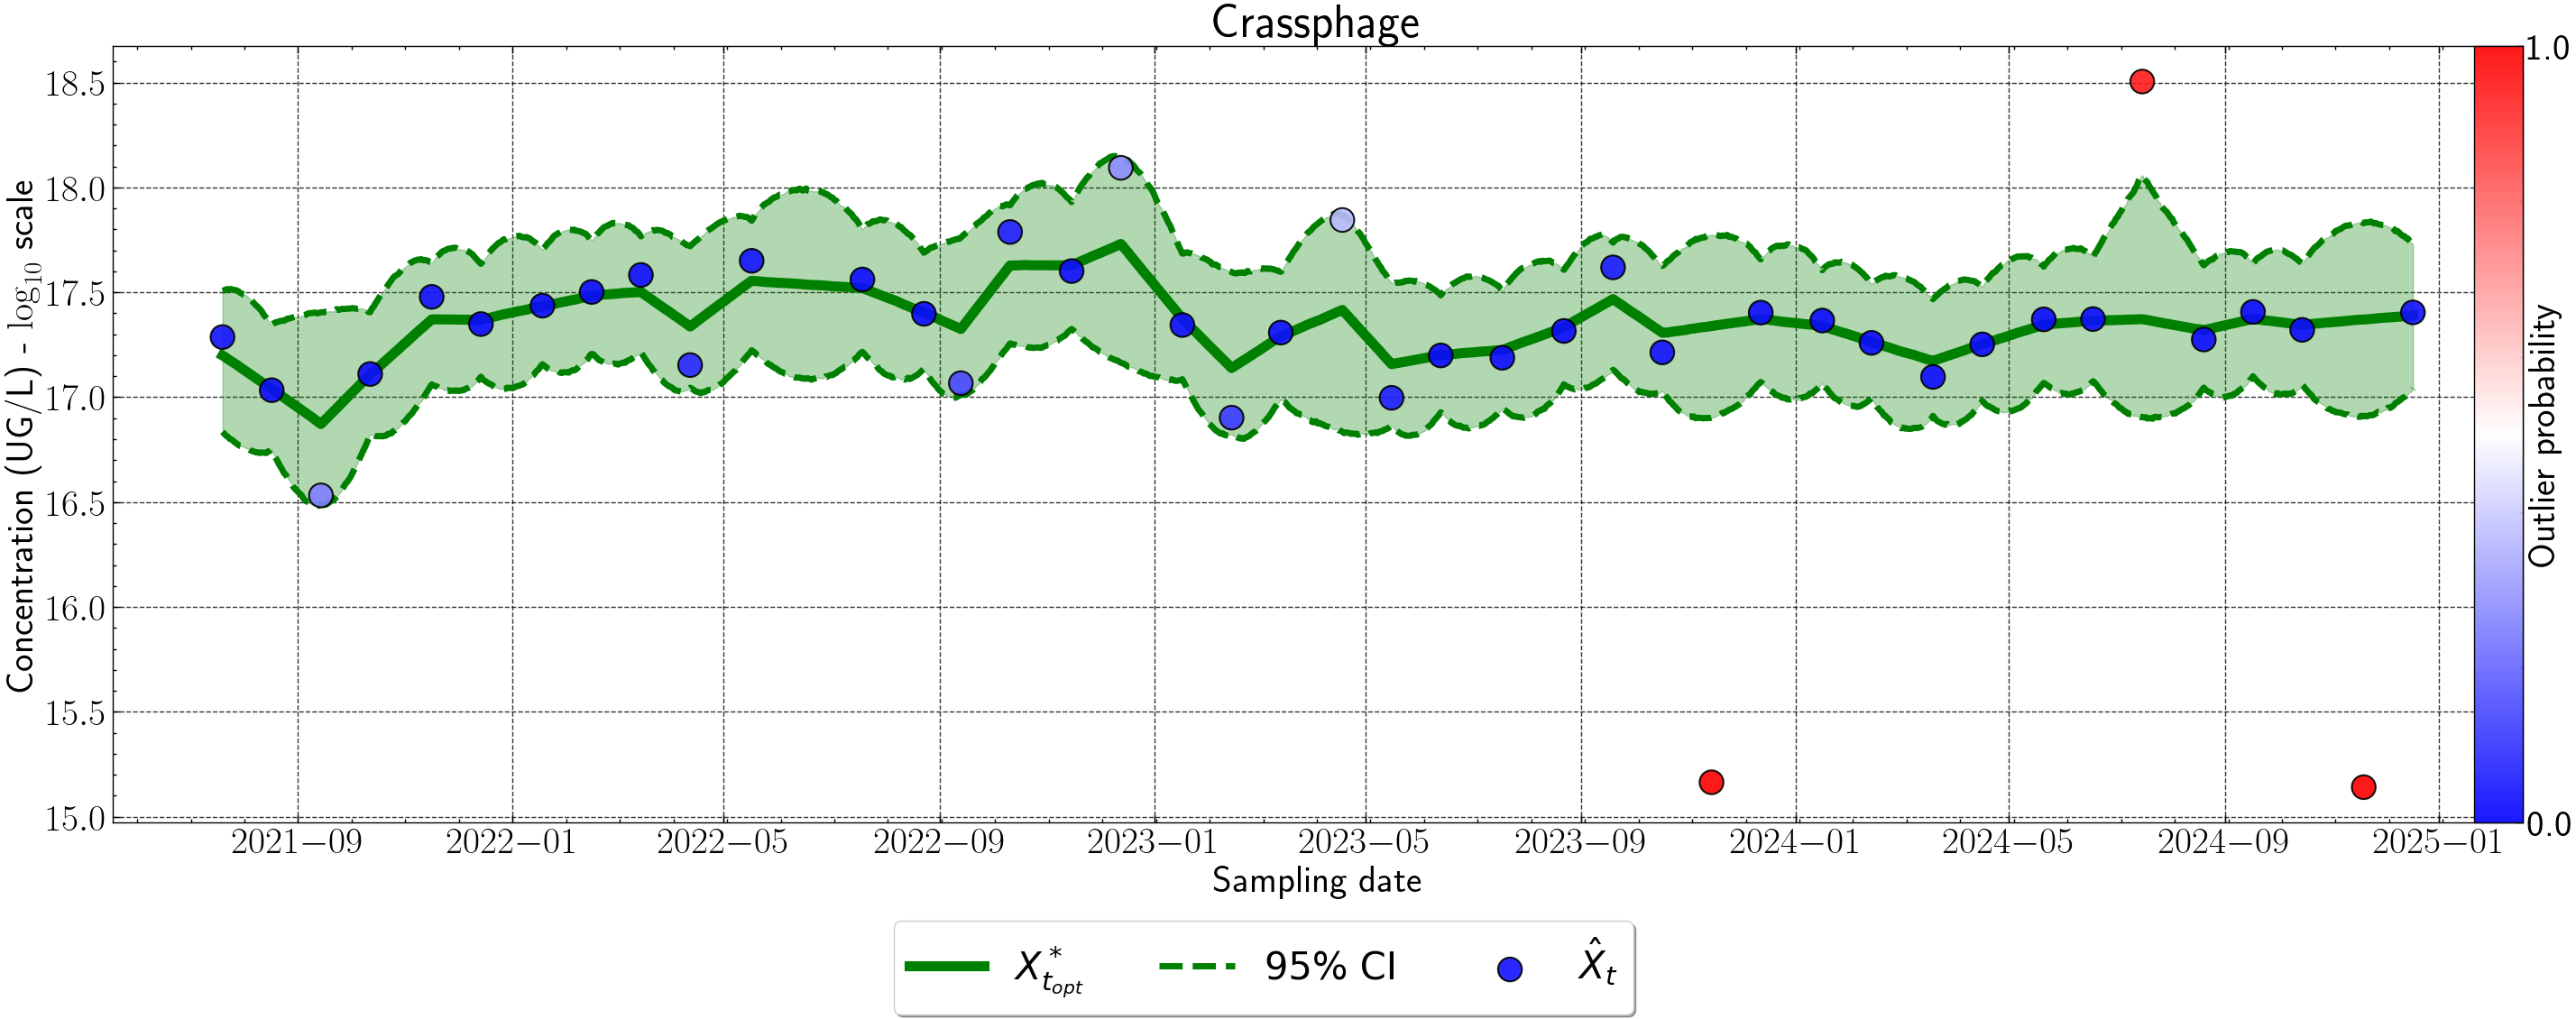

PMMoV (Pepper mild mottle virus)


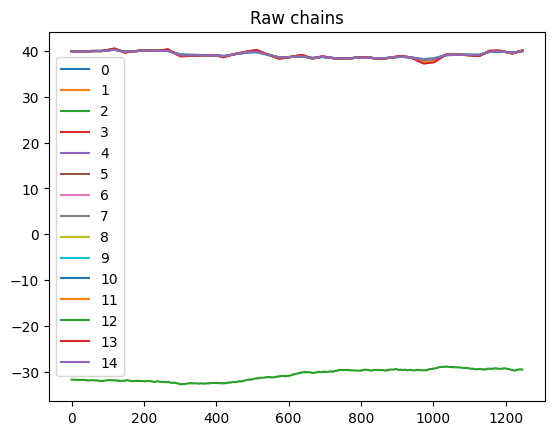

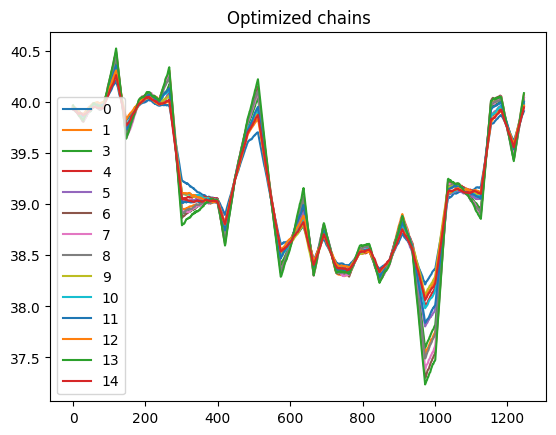

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.146  0.040   0.078    0.219      0.006    0.004      46.0     228.0   
eps    0.538  0.195   0.191    0.890      0.012    0.008     274.0    4062.0   
p_out  0.117  0.073   0.005    0.250      0.001    0.001    4428.0   16396.0   

       r_hat  
sig     1.24  
eps     1.04  
p_out   1.01  


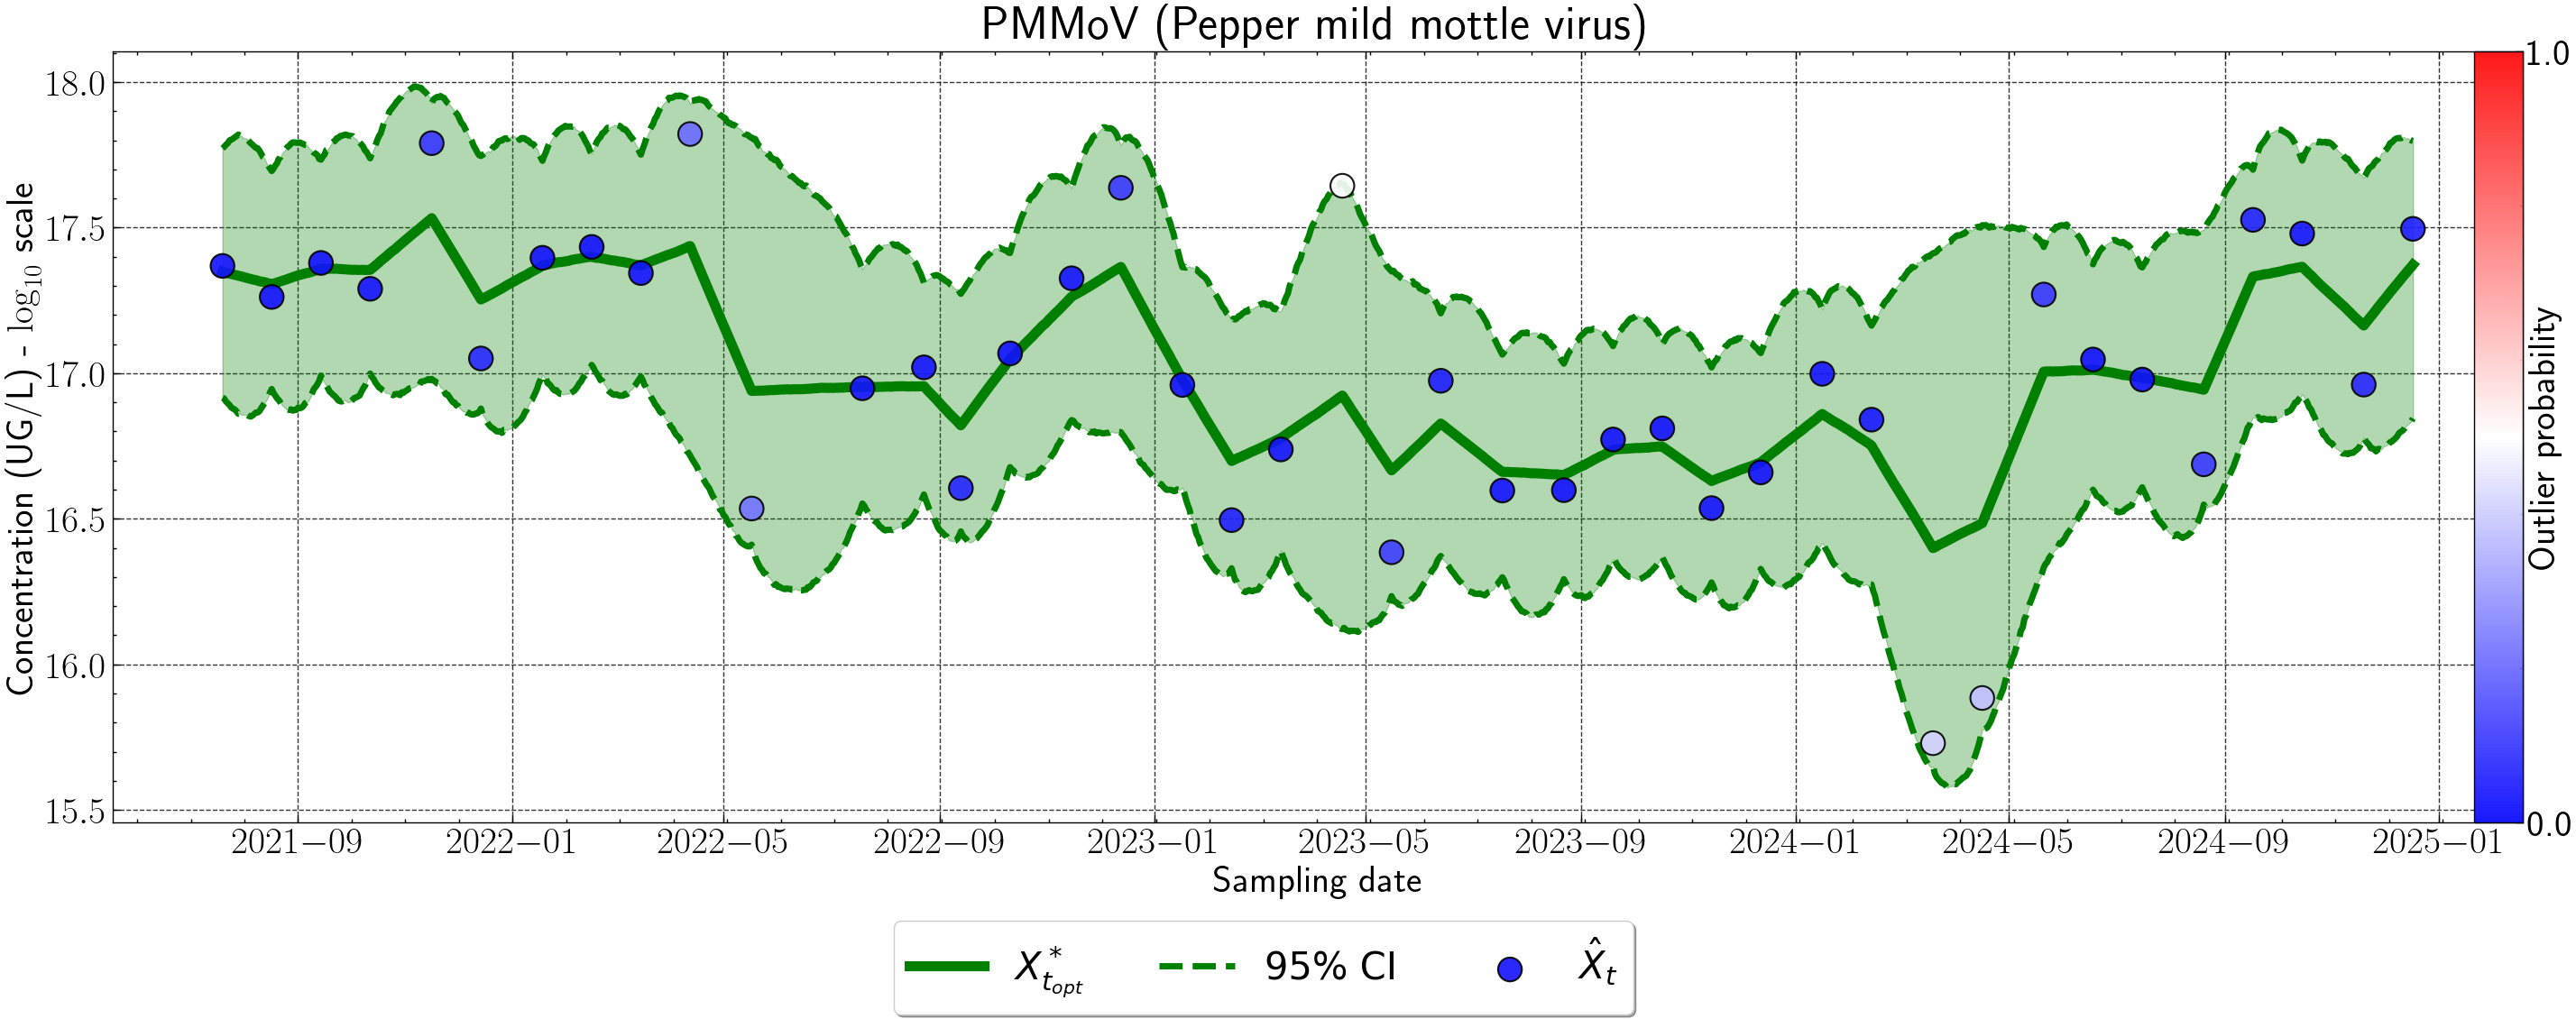

Astrovirus (8 serotypes)


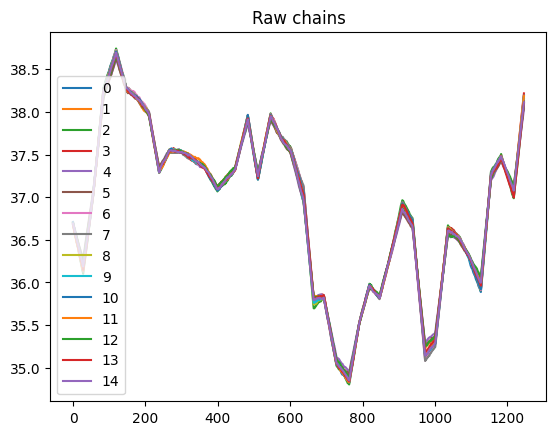

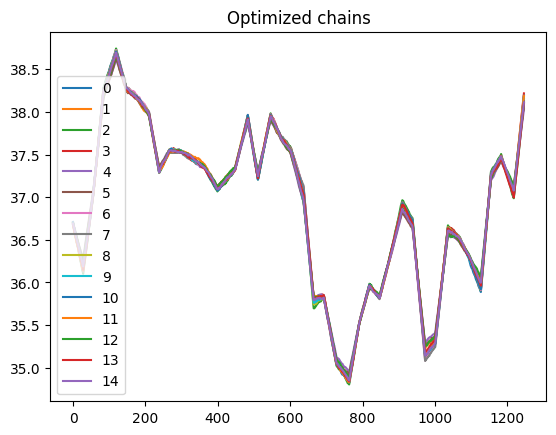

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.171  0.033   0.110    0.236      0.003    0.002     150.0     183.0   
eps    0.468  0.180   0.158    0.798      0.005    0.004    1109.0    4992.0   
p_out  0.112  0.056   0.018    0.214      0.000    0.000   19296.0   18371.0   

       r_hat  
sig     1.09  
eps     1.01  
p_out   1.00  


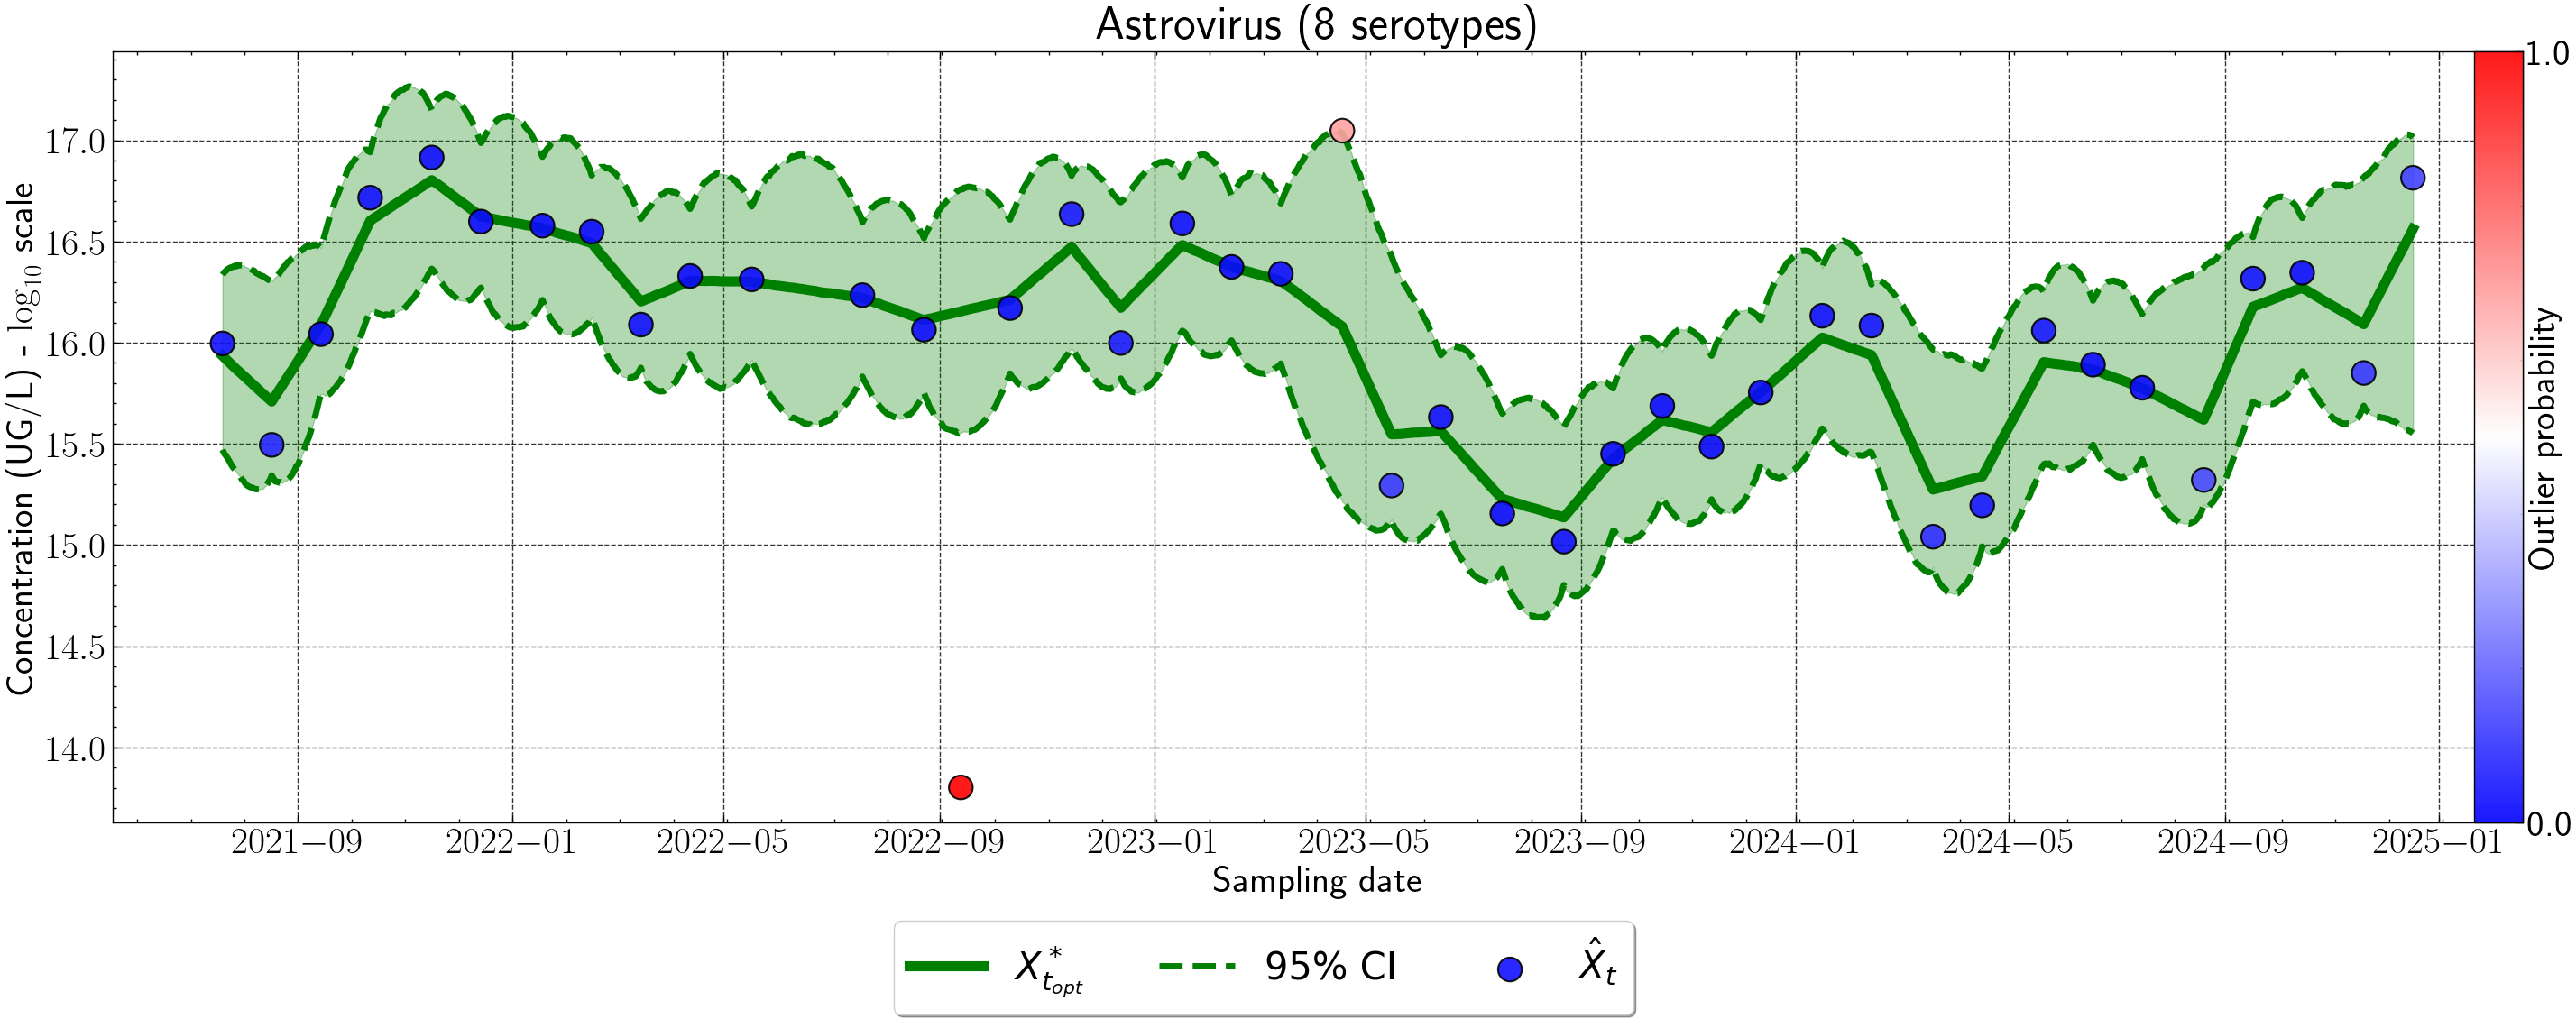

Norovirus-GI


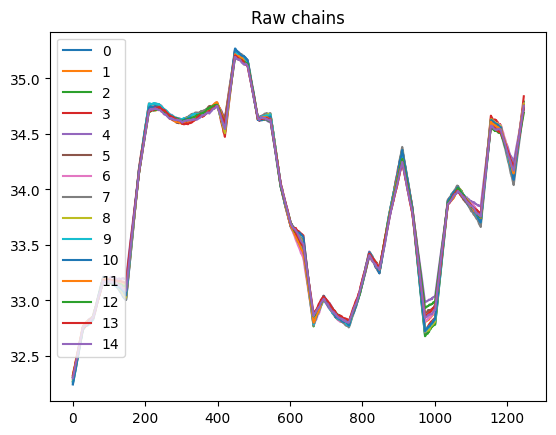

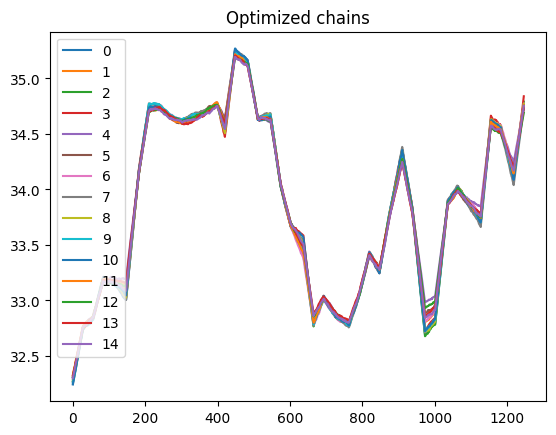

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.143  0.035   0.083    0.207      0.003    0.002     124.0     229.0   
eps    0.507  0.202   0.159    0.858      0.005    0.004    1770.0    6996.0   
p_out  0.136  0.080   0.008    0.279      0.001    0.001    7150.0   17753.0   

       r_hat  
sig     1.09  
eps     1.01  
p_out   1.00  


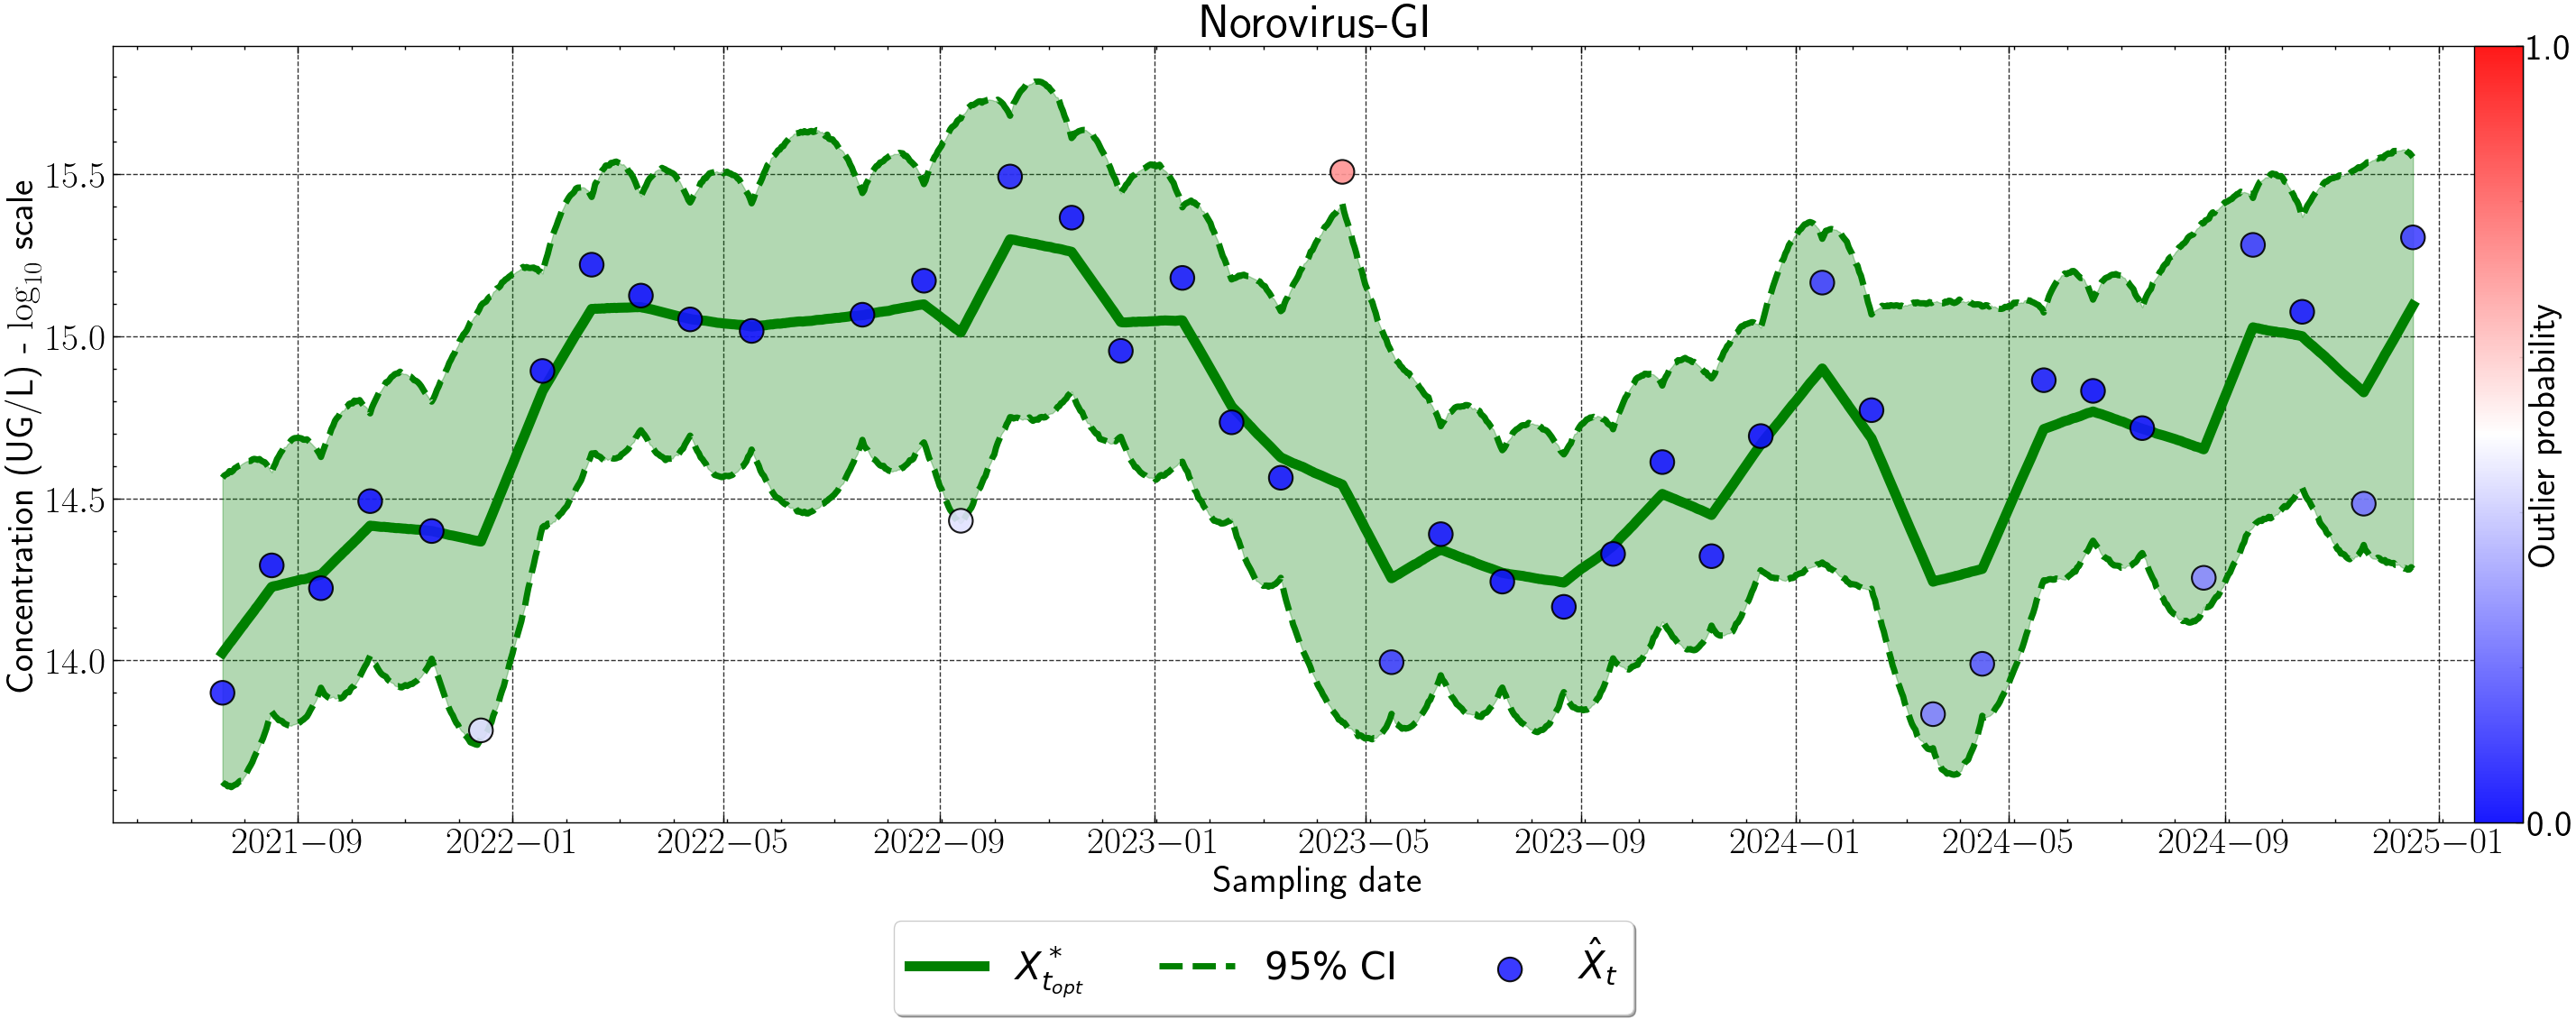

Norovirus-GII


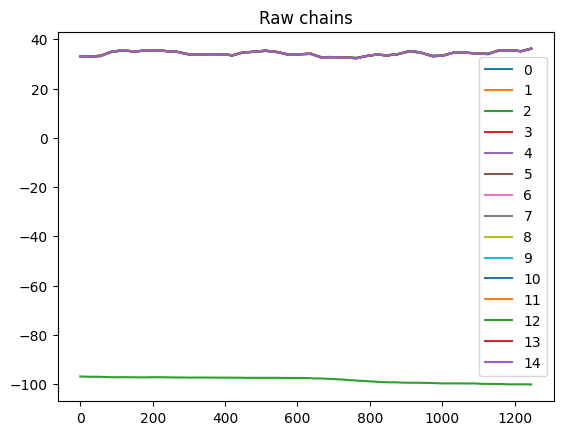

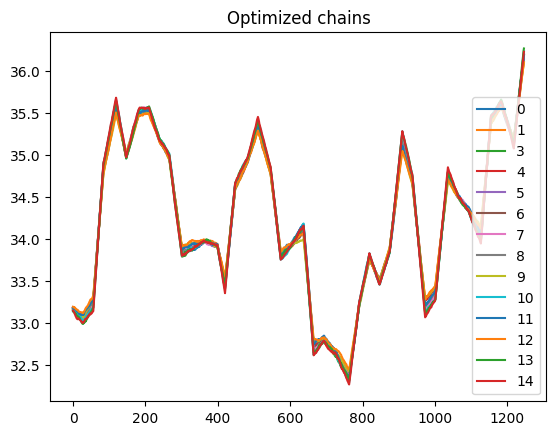

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.196  0.040   0.121    0.270      0.004    0.003     103.0     208.0   
eps    0.574  0.218   0.175    0.955      0.011    0.008     376.0    2557.0   
p_out  0.092  0.060   0.003    0.201      0.000    0.000   16177.0   17589.0   

       r_hat  
sig     1.10  
eps     1.03  
p_out   1.00  


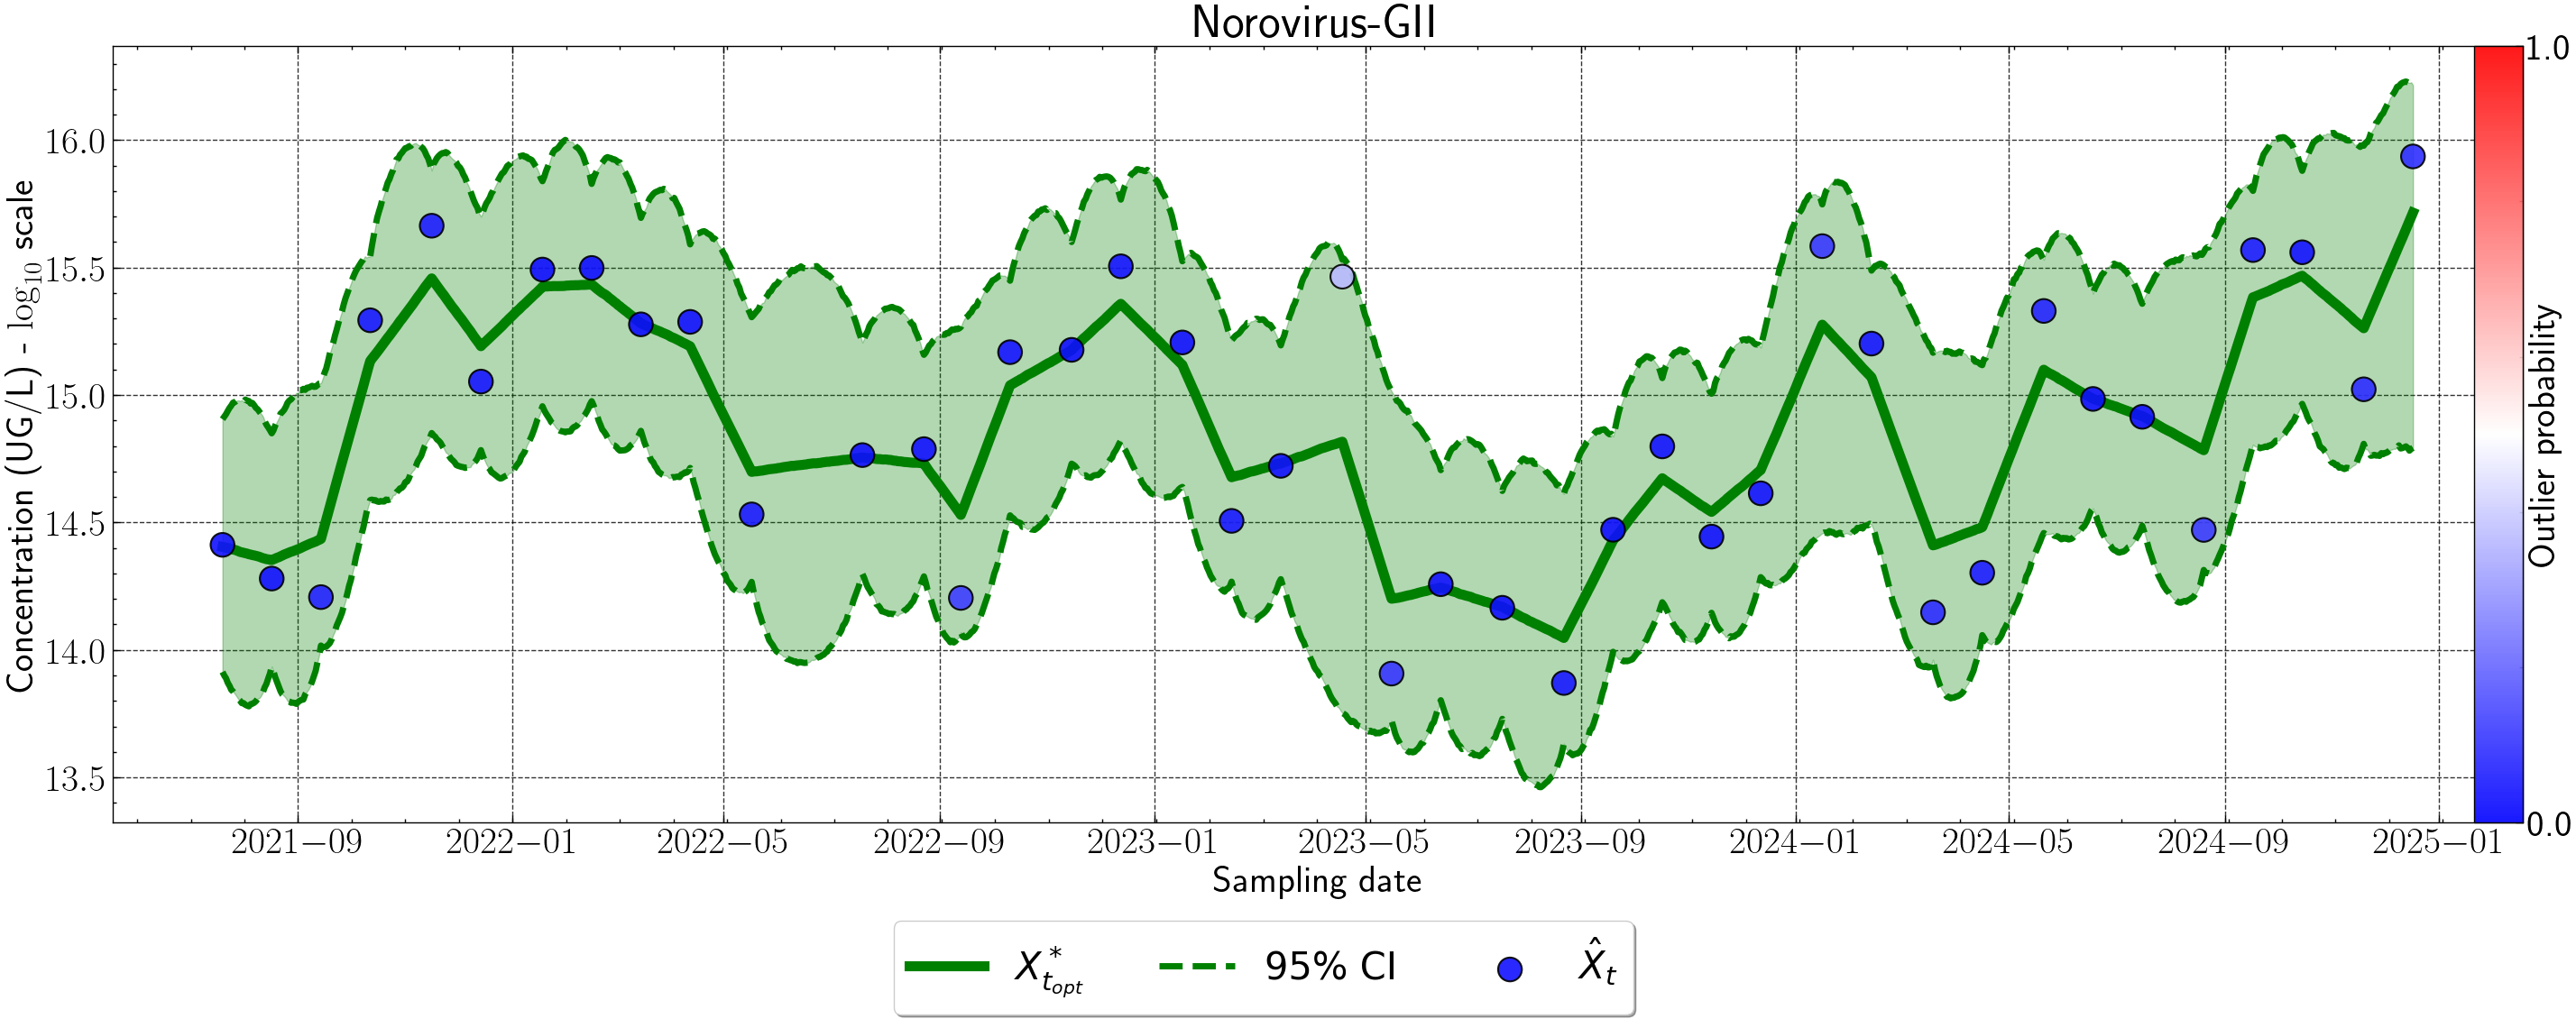

Aichi virus A


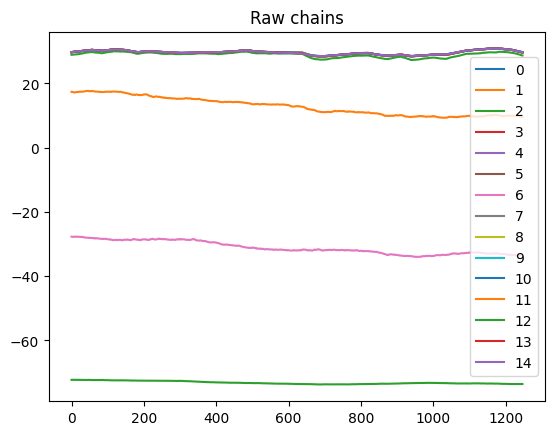

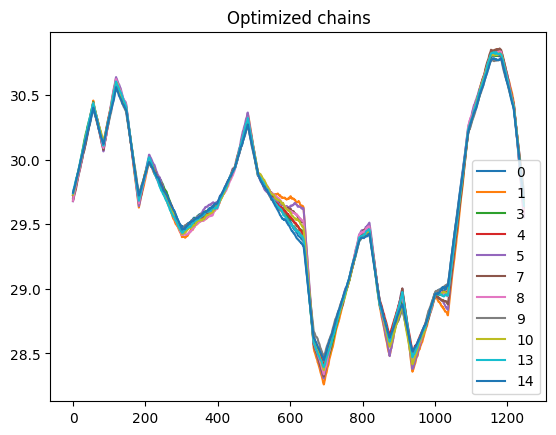

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.147  0.039   0.084    0.222      0.006    0.005      38.0      72.0   
eps    0.390  0.164   0.131    0.695      0.003    0.002    3440.0   11190.0   
p_out  0.168  0.082   0.032    0.321      0.001    0.001   12933.0   13645.0   

       r_hat  
sig     1.23  
eps     1.00  
p_out   1.00  


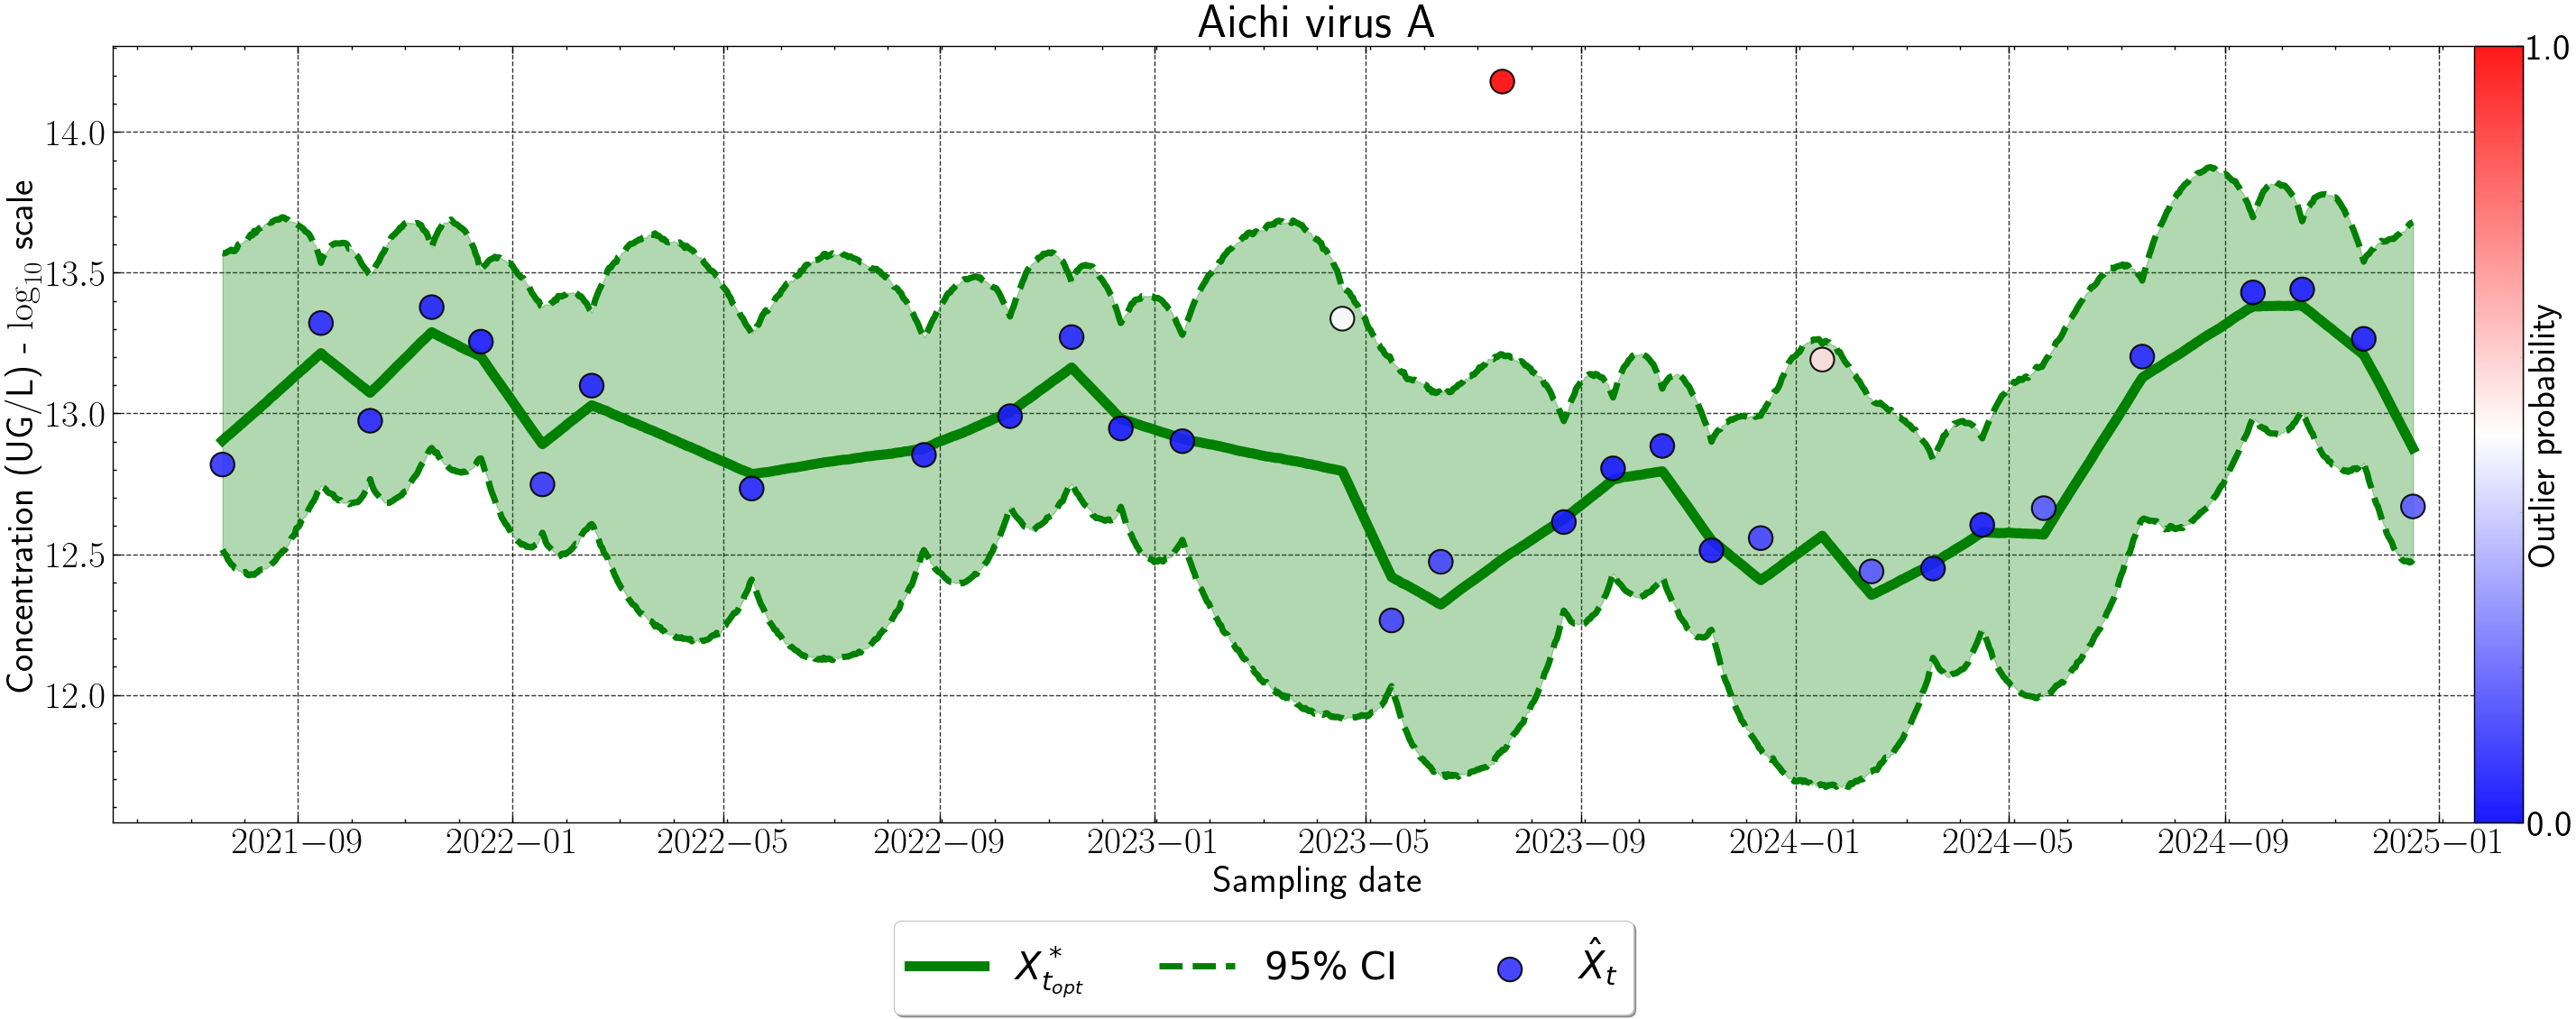

enterovirus (ABCD)


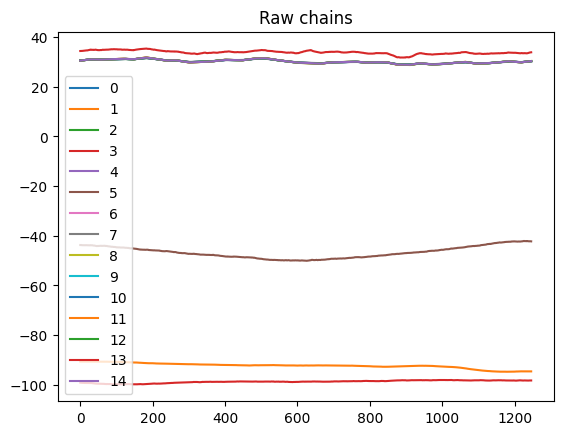

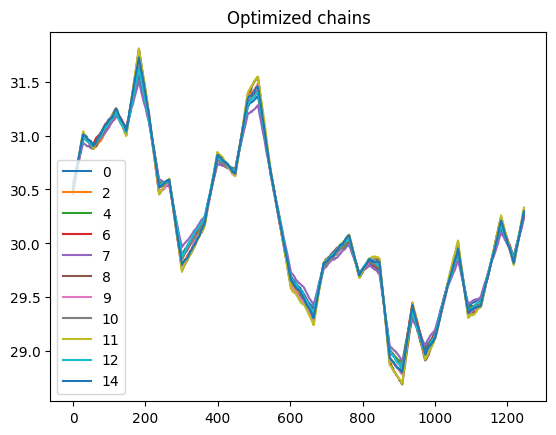

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.140  0.033   0.084    0.202      0.004    0.003      74.0     286.0   
eps    0.519  0.177   0.183    0.828      0.007    0.005     563.0    2954.0   
p_out  0.131  0.070   0.021    0.263      0.001    0.000   16163.0   13527.0   

       r_hat  
sig     1.13  
eps     1.02  
p_out   1.00  


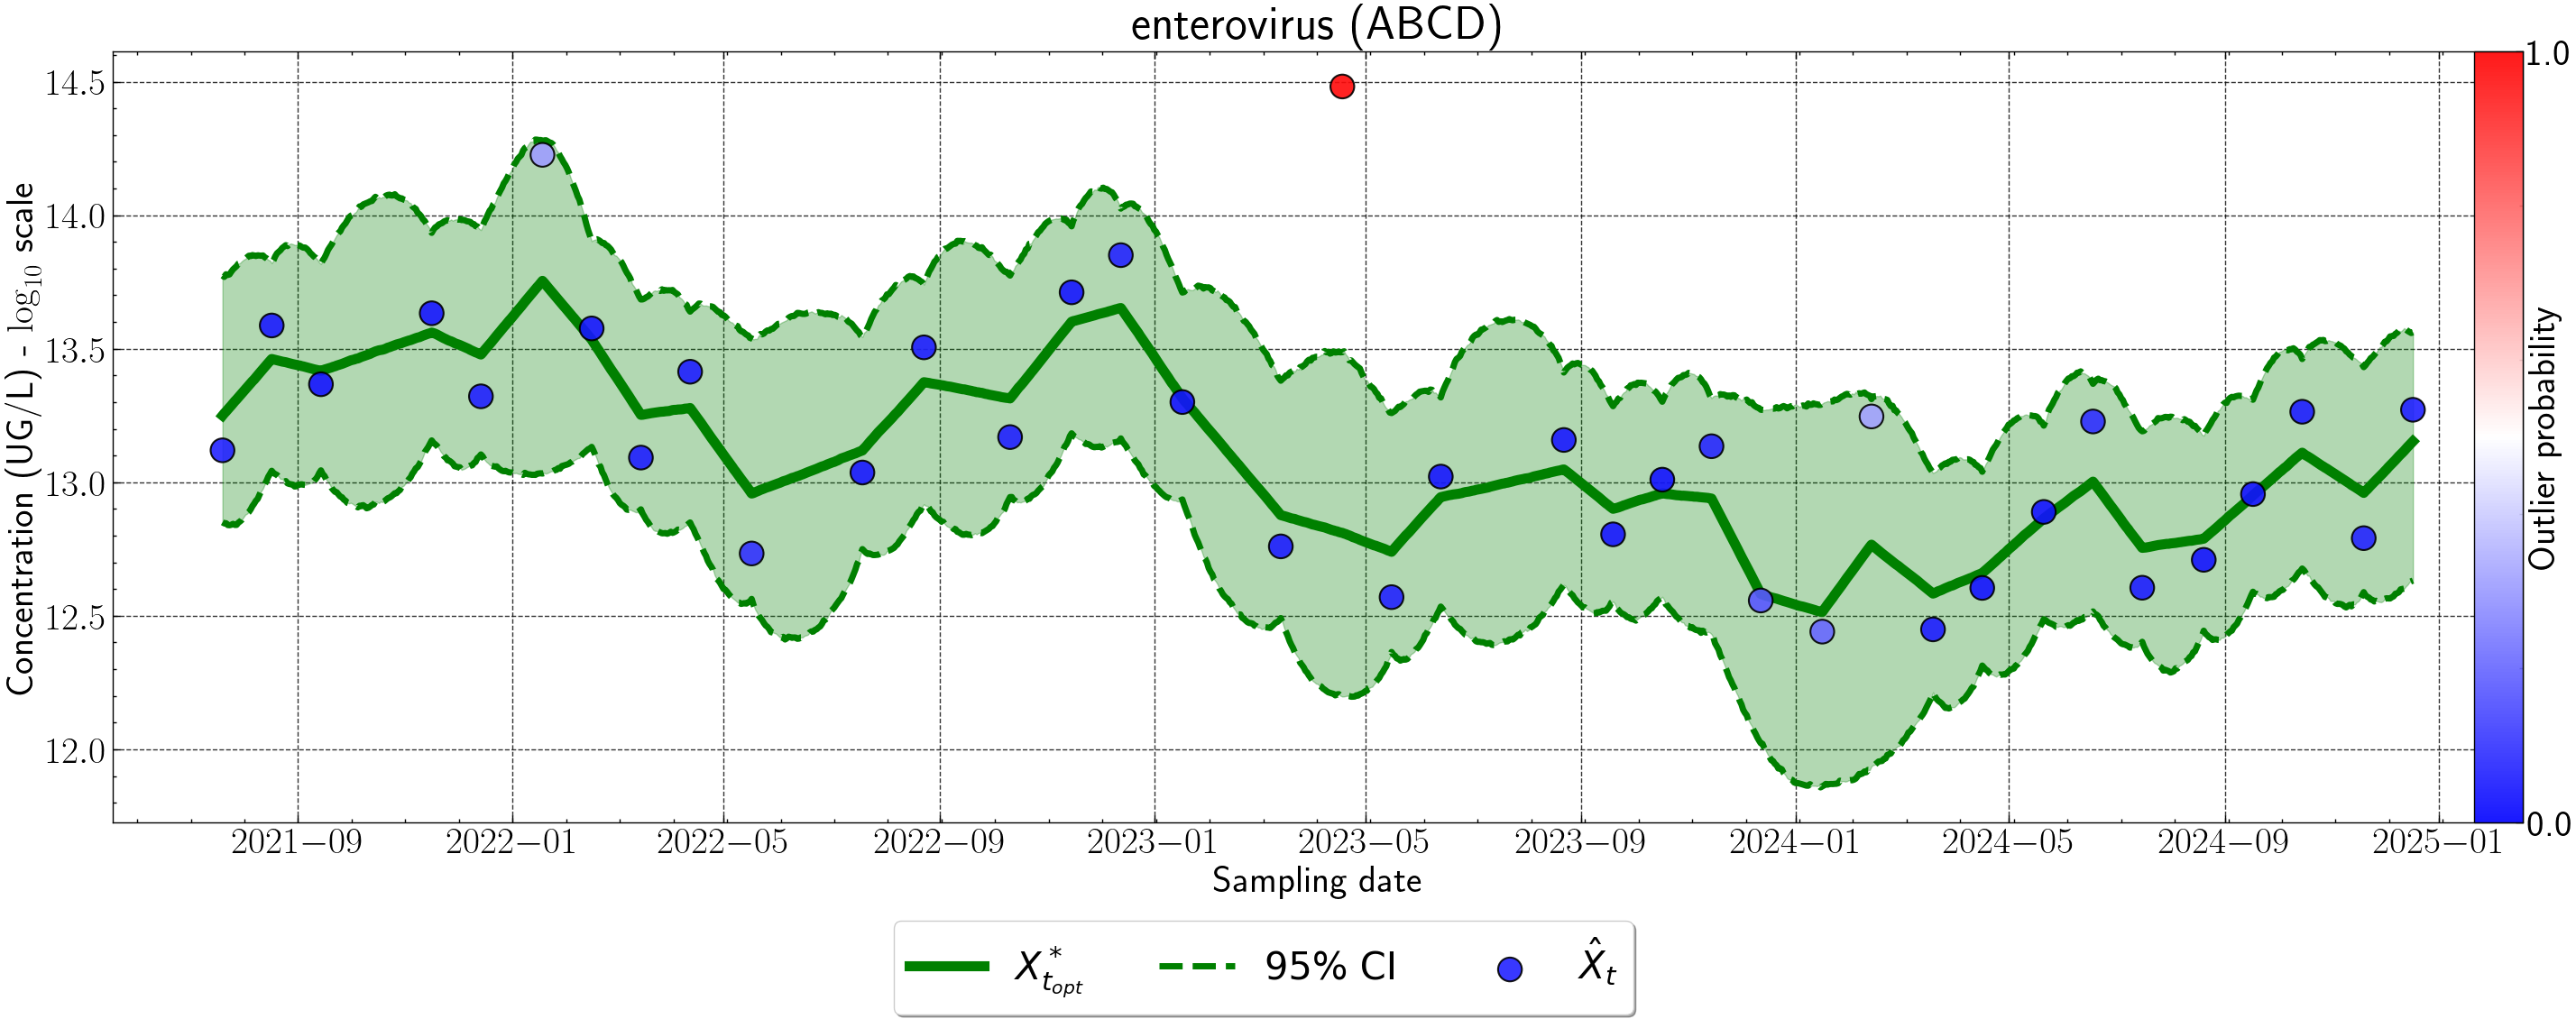

SAPOVIRUS GI/GII/GIV


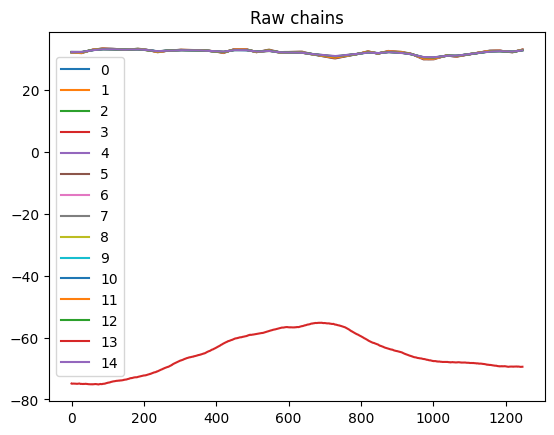

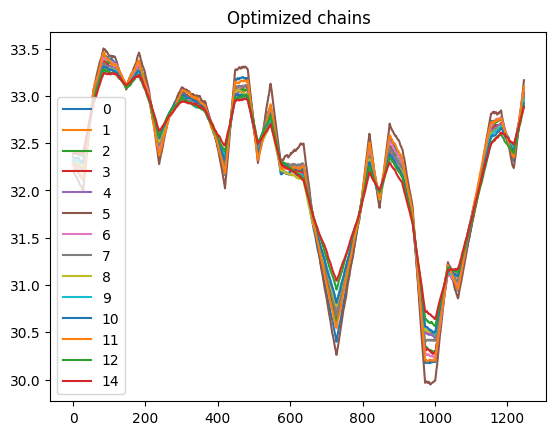

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.177  0.051   0.093    0.276      0.007    0.005      52.0     184.0   
eps    0.869  0.299   0.282    1.402      0.021    0.015     201.0    1435.0   
p_out  0.131  0.077   0.009    0.272      0.001    0.000   16274.0   17942.0   

       r_hat  
sig     1.20  
eps     1.05  
p_out   1.00  


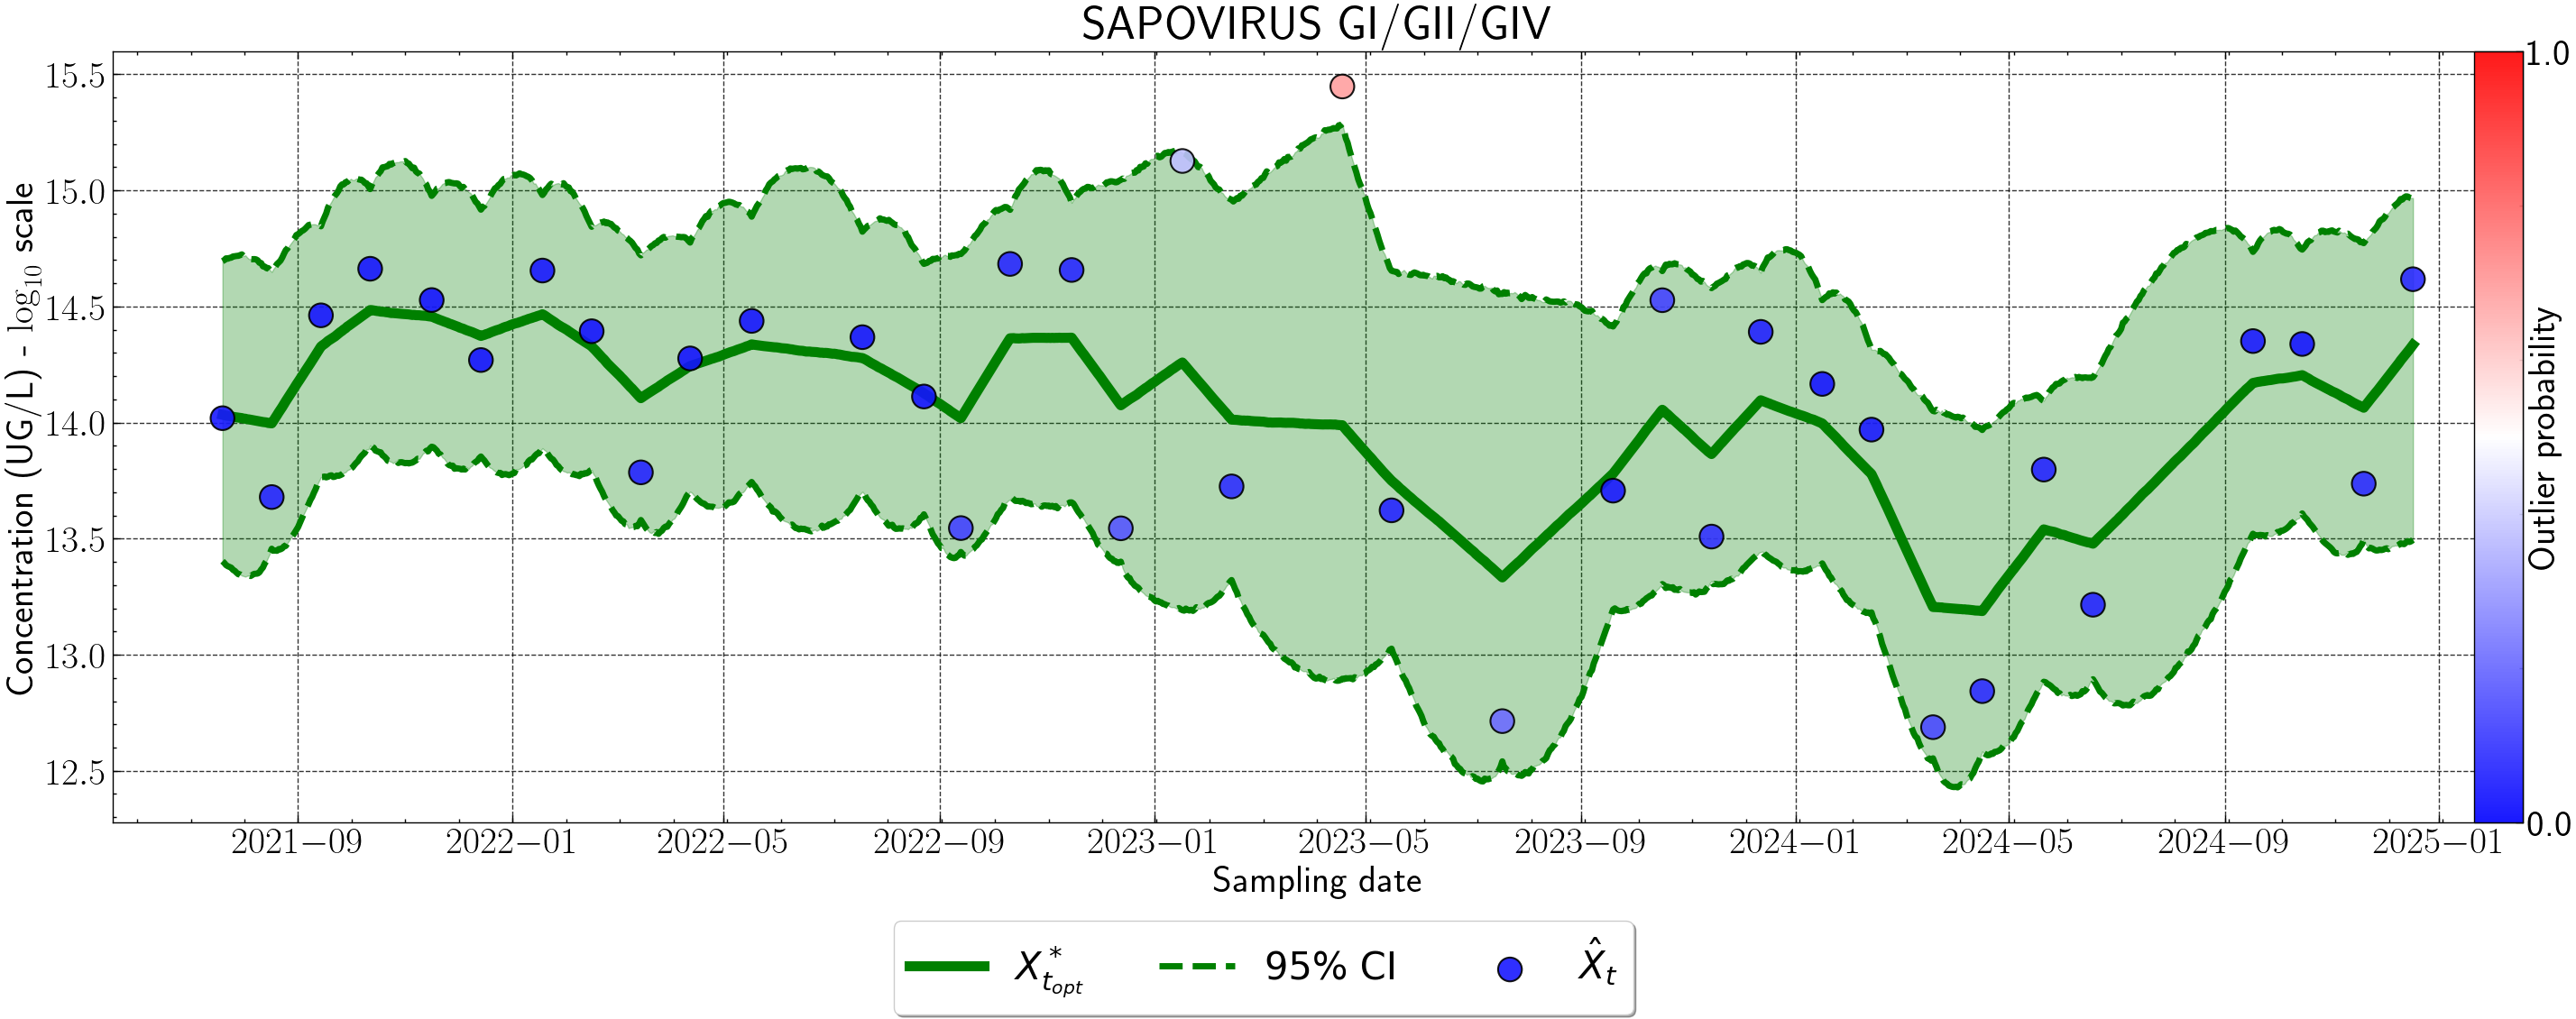

SARS-Cov2 (UG Gene E/L)


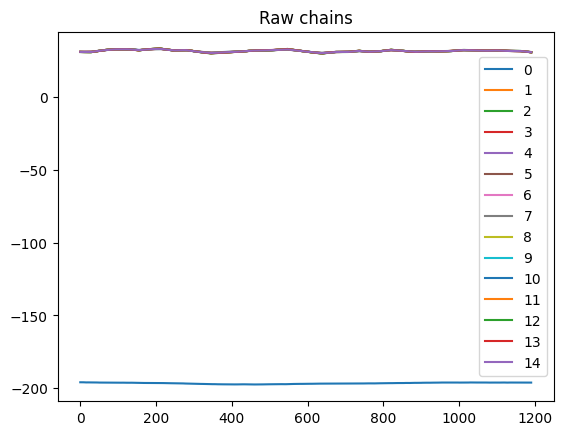

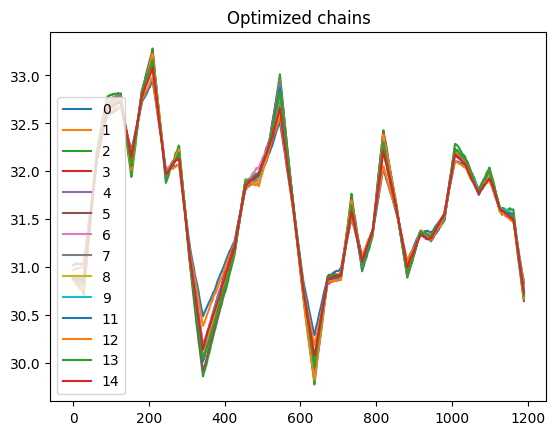

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.184  0.041   0.108    0.259      0.004    0.003      86.0     200.0   
eps    0.562  0.221   0.166    0.950      0.010    0.007     531.0    4072.0   
p_out  0.134  0.075   0.014    0.270      0.001    0.001    9201.0   19073.0   

       r_hat  
sig     1.13  
eps     1.02  
p_out   1.00  


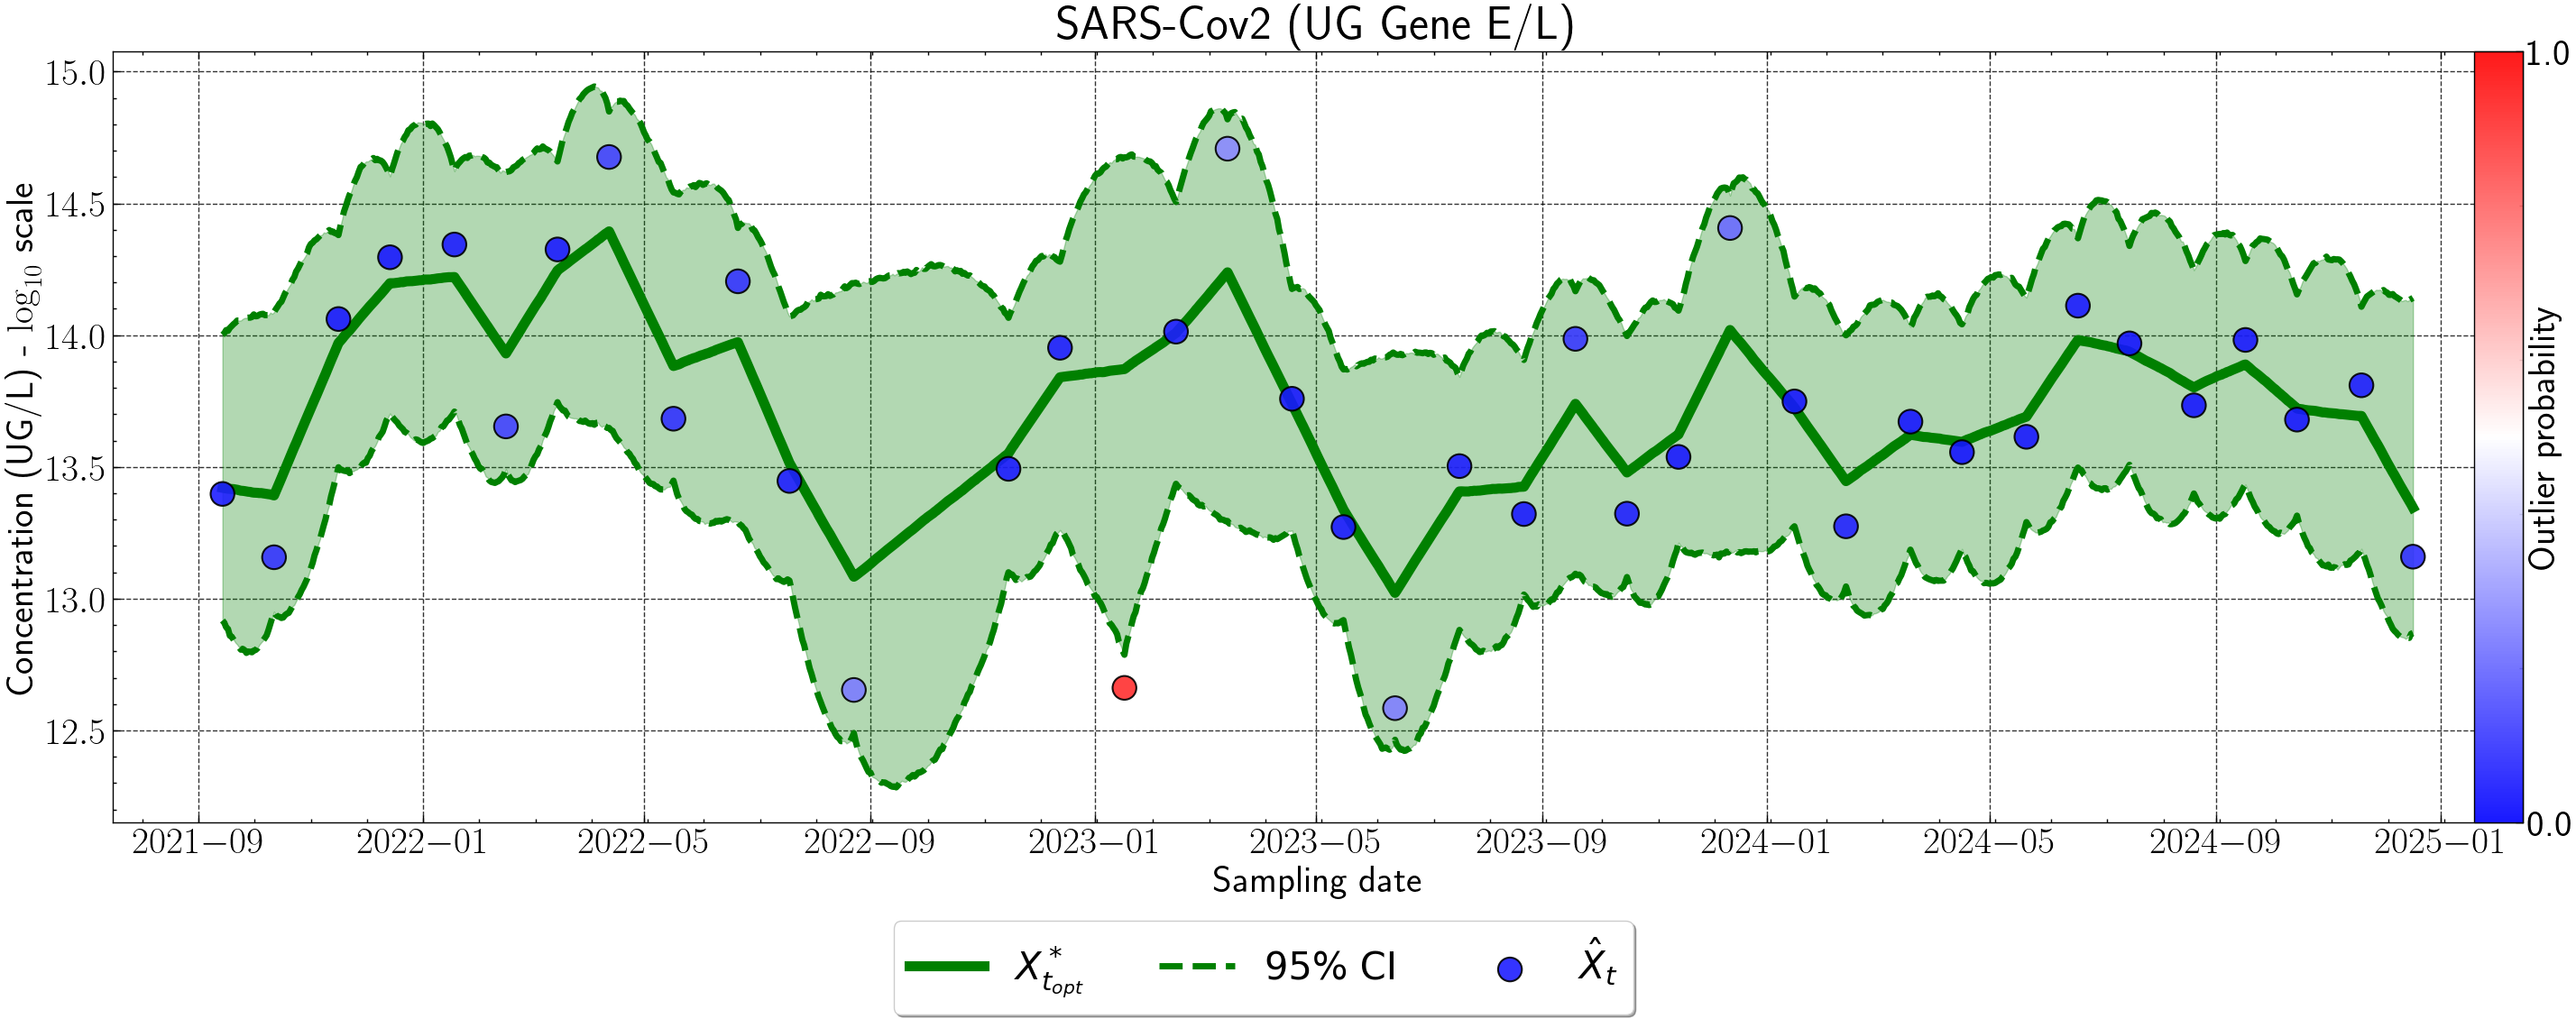

Rotavirus G1P[8], G2P[4], G3P[8], G4P[8], G9P[8] et G12P[8] (8G12)


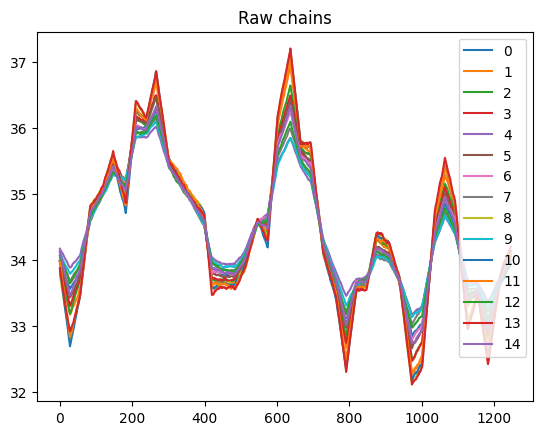

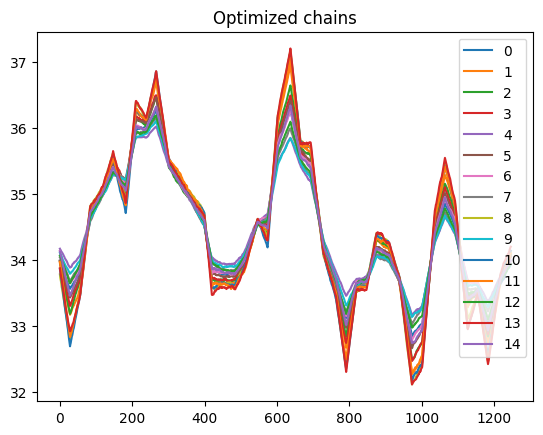

Best chain combination summary:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
sig    0.247  0.085   0.095    0.407      0.013    0.010      38.0      92.0   
eps    1.353  0.498   0.315    2.143      0.032    0.022     249.0    1783.0   
p_out  0.132  0.088   0.006    0.296      0.001    0.001    9026.0   10702.0   

       r_hat  
sig     1.33  
eps     1.04  
p_out   1.00  


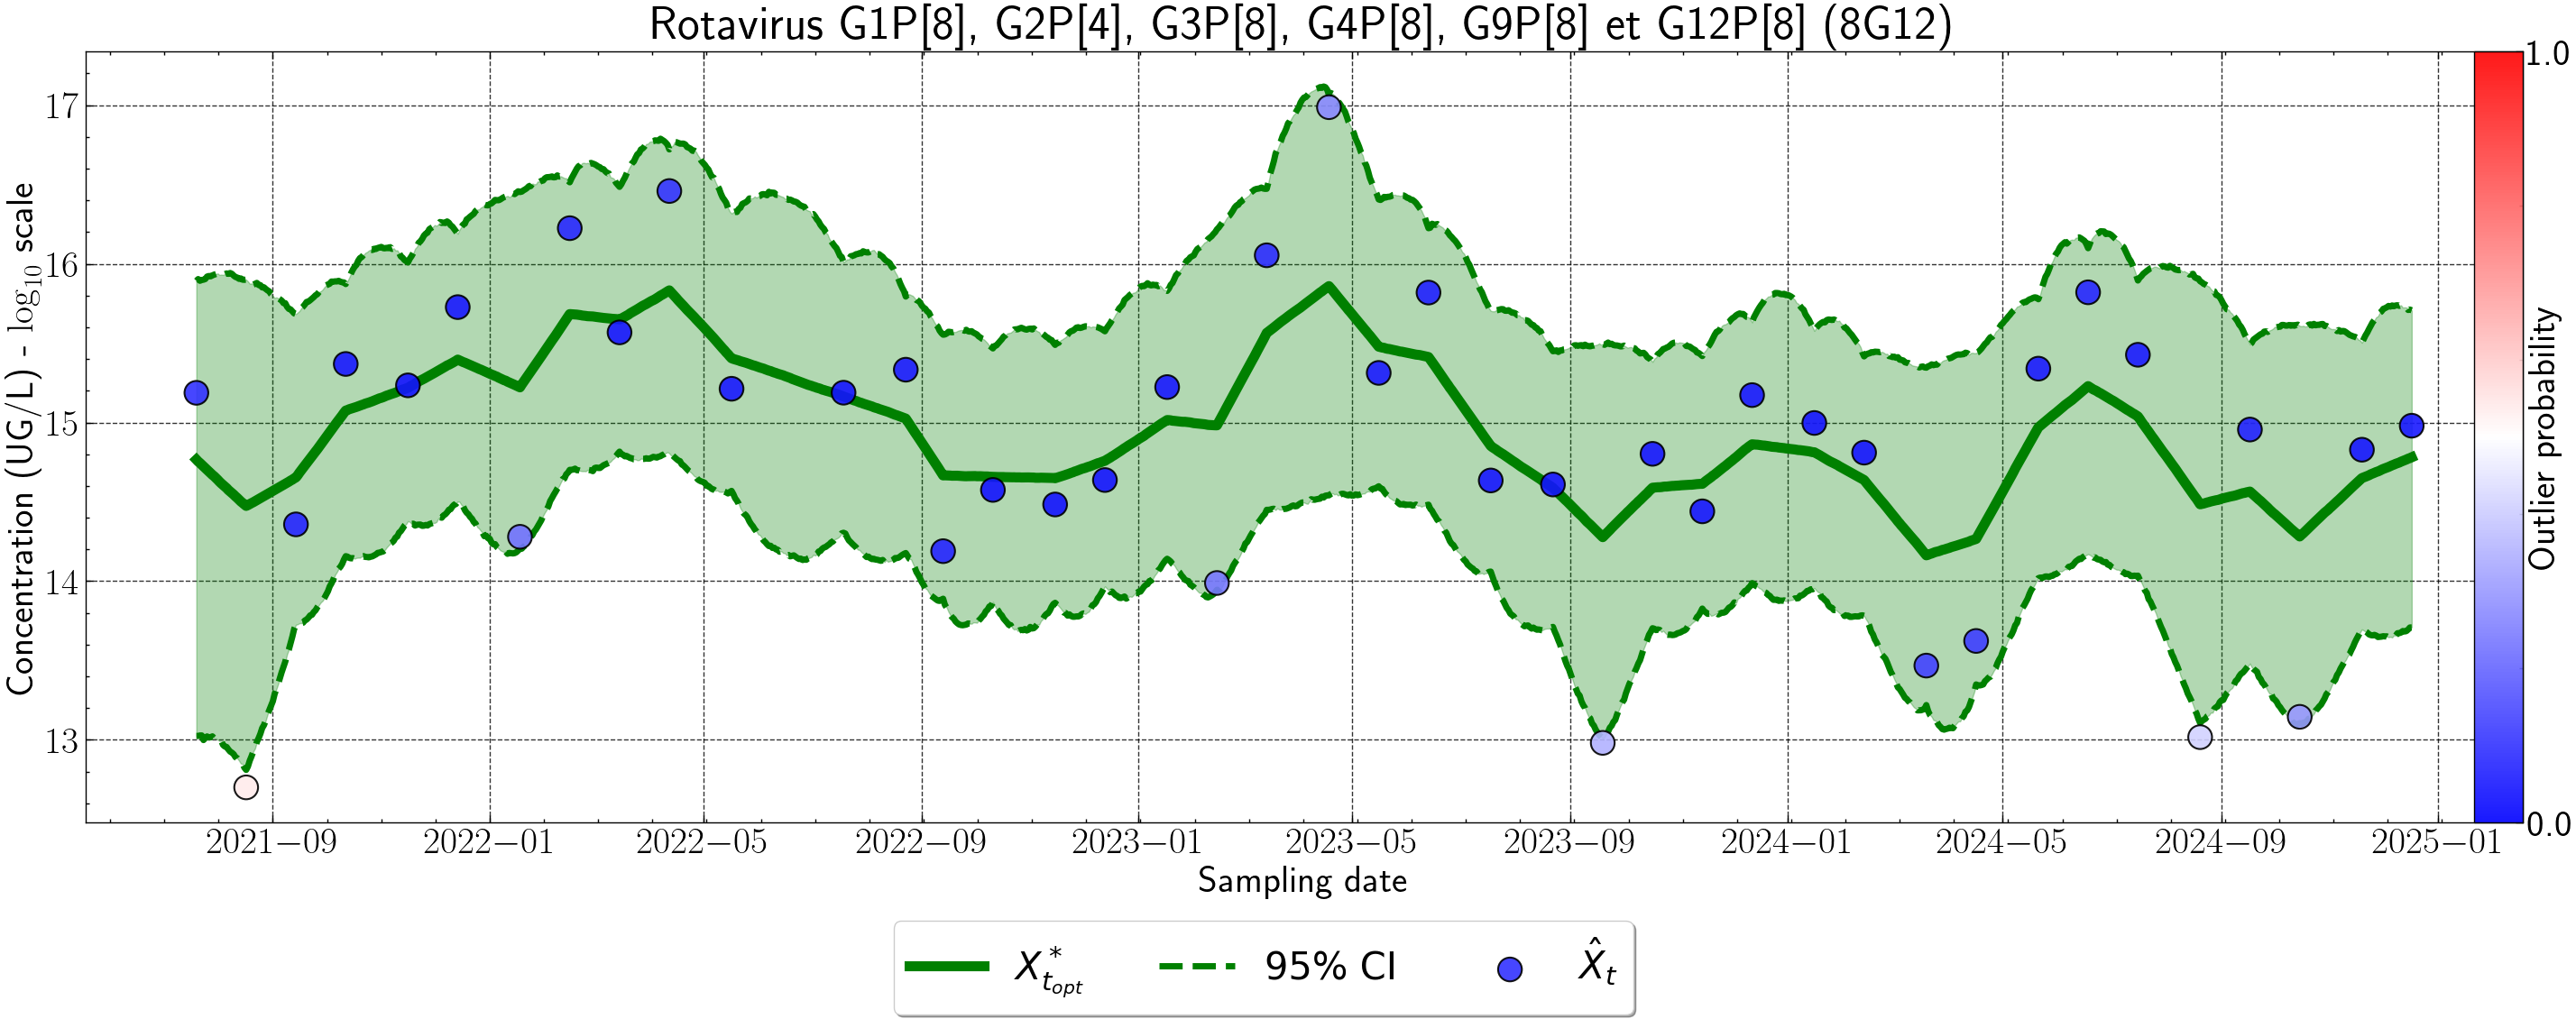

In [11]:
common_flux_data = {}
### Global loop
for this_parameter in viruses_list:

    print("==========")
    print(this_parameter)
    print("==========")
        
    scou = scou_dict[this_parameter]
    sub_data = sub_data_dict[this_parameter]

    selected_chains = np.arange(nb_chains).tolist()
    remove_those = chain_selector_dict[this_parameter]
    for i in remove_those:
        selected_chains.remove(i)
    
    scou.visualize_latents(selected_chains)
    scou.predict(selected_chains)

    sub_data = append_and_process_results(sub_data, this_parameter, scou)
    visualize_results(sub_data, this_parameter)

In [12]:
for parameter in list(common_flux_data.keys()):
    this_file = common_flux_data[parameter]

    if parameter=='SAPOVIRUS GI/GII/GIV':
        tm = 'SAPOVIRUS'
    elif parameter=='SARS-Cov2 (UG Gene E/L)':
        tm = 'SARS-CoV-2'
    else:
        tm = parameter
    
    this_file.to_csv('../../outputs/files/viral_data/' + tm + '.csv', sep=';', index=False)